# EcoBin: A Two Stage Waste Classification Model

The United States alone generated over [292.4 million tons of Municipal Solid Waste in 2018](https://www.epa.gov/facts-and-figures-about-materials-waste-and-recycling/national-overview-facts-and-figures-materials), and only about a third of it actually made it to a recycling or composting facility. A big part of the gap is contamination: a single greasy pizza box or half-full soda bottle can spoil an entire batch of otherwise recyclable material at the sorting plant.

EcoBin is built around that observation. Stage A looks at an image and predicts what kind of waste it is, mapping the prediction to one of four disposal pathways (curbside recycling, drop-off recycling, compost, or garbage). Stage B is a second pass that only runs when Stage A predicts a recyclable item; it checks the surface for visible contamination and, if it finds any, overrides the decision to garbage. The notebook trains both stages end to end and saves them for the EcoBin dashboard.

## Step 0: Import Libraries

Set up the runtime so the rest of the notebook runs cleanly. The first cell silences harmless CUDA factory warnings, pins numpy to a version TensorFlow 2.19 is happy with, imports everything every later cell needs, and creates the output folders that get written to during the Kaggle run.

In [ ]:
# Silence Kaggle CUDA factory-registration warnings before TensorFlow imports
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Kaggle's base image ships numpy 2.4 which is incompatible with TF 2.19.
# Reset it to a known-good range before any TF import touches the C extension.
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "numpy<2.2,>=1.26", "--force-reinstall", "--no-deps"])

import gc
import json
import random
import shutil
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns

from pathlib import Path
from PIL import Image
from collections import Counter

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

IMG_SIZE   = 224
BATCH_SIZE = 32
SEED       = 42

# Folders for everything the notebook saves to disk during the Kaggle run
WORKING_PATH         = Path("/kaggle/working")
DATASET_AUDIT_PATH   = WORKING_PATH / "Waste Classification Dataset Audit"
MODELS_PATH          = WORKING_PATH / "Models"
STAGE_A_RESULTS_PATH = WORKING_PATH / "Stage A Results"
STAGE_B_RESULTS_PATH = WORKING_PATH / "Stage B Results"

for _dir in [DATASET_AUDIT_PATH, MODELS_PATH, STAGE_A_RESULTS_PATH, STAGE_B_RESULTS_PATH]:
    _dir.mkdir(parents=True, exist_ok=True)

# Seed everything for reproducible splits
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow", tf.__version__, "| numpy", np.__version__)
print("GPUs visible:", len(tf.config.list_physical_devices("GPU")))


## Step 1: Prepare Waste Classification Dataset

### 1.1 Set the Dataset Path

The Recyclable and Household Waste Classification Dataset is already mounted on Kaggle, so the path constants are bound directly. No download step needed.

The training data comes from the [Recyclable and Household Waste Classification Dataset](https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification) on Kaggle. It has 30 classes of household waste with around 350 images per class. Each class has two subfolders: a `default` set of product-style photos on neutral backgrounds, and a `real_world` set of in-the-wild photos. The notebook uses both and treats the difference as a built-in domain-gap test in section 2.8.

In [ ]:
# The dataset is pre-mounted on Kaggle, no download step needed
DATASET_PATH = Path("/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images")
SPLITS_PATH  = Path("/kaggle/working/splits")
print(f"Dataset path : {DATASET_PATH}")
print(f"Splits path  : {SPLITS_PATH}")


### 1.2 Set the Random Seed

Fix a single seed so every split, every shuffle, and every weight initialisation is reproducible. Anyone re-running the notebook gets the same numbers.

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### 1.3 Map Each Class of Waste to a Disposal Pathway

Each of the 30 classes needs to map to one of four disposal pathways: **curbside recycling**, **drop-off recycling**, **compost**, or **garbage**. The mapping is hardcoded here because municipal rules vary by region. Curbside recycling covers things every standard kerbside bin accepts (paper, cardboard, rigid plastics, metal cans, glass bottles). Drop-off recycling is for items that need a specialty bin (plastic bags, soft plastics). Compost is for food and organic matter. Garbage is everything else.

In [ ]:
class_names = sorted(p.name for p in DATASET_PATH.iterdir() if p.is_dir())
print(f"Found {len(class_names)} classes in {DATASET_PATH.name}")


In [5]:
# Initializes a dictionary mapping each class of waste within the dataset to a disposal pathway
DISPOSAL_MAP = {

    # Curbside Recycling: 17 classes
    'plastic_soda_bottles':       'curbside_recycling',
    'aerosol_cans':               'curbside_recycling',
    'steel_food_cans':            'curbside_recycling',
    'cardboard_boxes':            'curbside_recycling',
    'glass_beverage_bottles':     'curbside_recycling',
    'plastic_cup_lids':           'curbside_recycling',
    'cardboard_packaging':        'curbside_recycling',
    'glass_food_jars':            'curbside_recycling',
    'aluminum_food_cans':         'curbside_recycling',
    'plastic_food_containers':    'curbside_recycling',
    'magazines':                  'curbside_recycling',
    'aluminum_soda_cans':         'curbside_recycling',
    'plastic_detergent_bottles':  'curbside_recycling',
    'newspaper':                  'curbside_recycling',
    'office_paper':               'curbside_recycling',
    'plastic_water_bottles':      'curbside_recycling',
    'glass_cosmetic_containers':  'curbside_recycling',

    # Drop-off Recycling: 4 classes
    'plastic_shopping_bags':      'dropoff_recycling',
    'plastic_trash_bags':         'dropoff_recycling',
    'clothing':                   'dropoff_recycling',
    'shoes':                      'dropoff_recycling',

    # Compsot: 4 classes
    'eggshells':                  'compost',
    'coffee_grounds':             'compost',
    'tea_bags':                   'compost',
    'food_waste':                 'compost',

    # Garbage: 5 classes
    'disposable_plastic_cutlery': 'garbage',
    'styrofoam_cups':             'garbage',
    'styrofoam_food_containers':  'garbage',
    'plastic_straws':             'garbage',
    'paper_cups':                 'garbage',
}

### 1.4 Display Class Distribution

Before training, check that no class is so under-represented that the model cannot learn it. The bar chart below shows image counts per class, colored by the disposal pathway each class maps to.

In [6]:
#==============-
# Table View
# ==============

# Appends each class of waste with disposal pathway and number of images into an empty array named records
records = []
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name
    count = sum(1 for f in class_dir.rglob('*') if f.is_file())
    pathway = DISPOSAL_MAP.get(class_name, 'UNMAPPED')
    records.append({'class': class_name, 'count': count, 'pathway': pathway}) # Appends image count and disposal route onto record

# Sorts values in the dataframe by count
df = pd.DataFrame(records).sort_values('count', ascending=False)

# Calculate percent composition of each class out of total dataset size
df['pct'] = (df['count'] / df['count'].sum() * 100).round(2)

# Print table and write csv to Waste Classification Dataset Audit
print(df[['class', 'count', 'pct', 'pathway']].to_string(index=False))
table_path = DATASET_AUDIT_PATH / 'class_distribution_table.csv'
df[['class', 'count', 'pct', 'pathway']].to_csv(table_path, index=False)
print(f"\nSaved to {table_path}")

                     class  count  pct            pathway
              aerosol_cans    500 3.33 curbside_recycling
        aluminum_food_cans    500 3.33 curbside_recycling
        aluminum_soda_cans    500 3.33 curbside_recycling
           cardboard_boxes    500 3.33 curbside_recycling
       cardboard_packaging    500 3.33 curbside_recycling
                  clothing    500 3.33  dropoff_recycling
            coffee_grounds    500 3.33            compost
disposable_plastic_cutlery    500 3.33            garbage
                 eggshells    500 3.33            compost
                food_waste    500 3.33            compost
    glass_beverage_bottles    500 3.33 curbside_recycling
 glass_cosmetic_containers    500 3.33 curbside_recycling
           glass_food_jars    500 3.33 curbside_recycling
                 magazines    500 3.33 curbside_recycling
                 newspaper    500 3.33 curbside_recycling
              office_paper    500 3.33 curbside_recycling
              

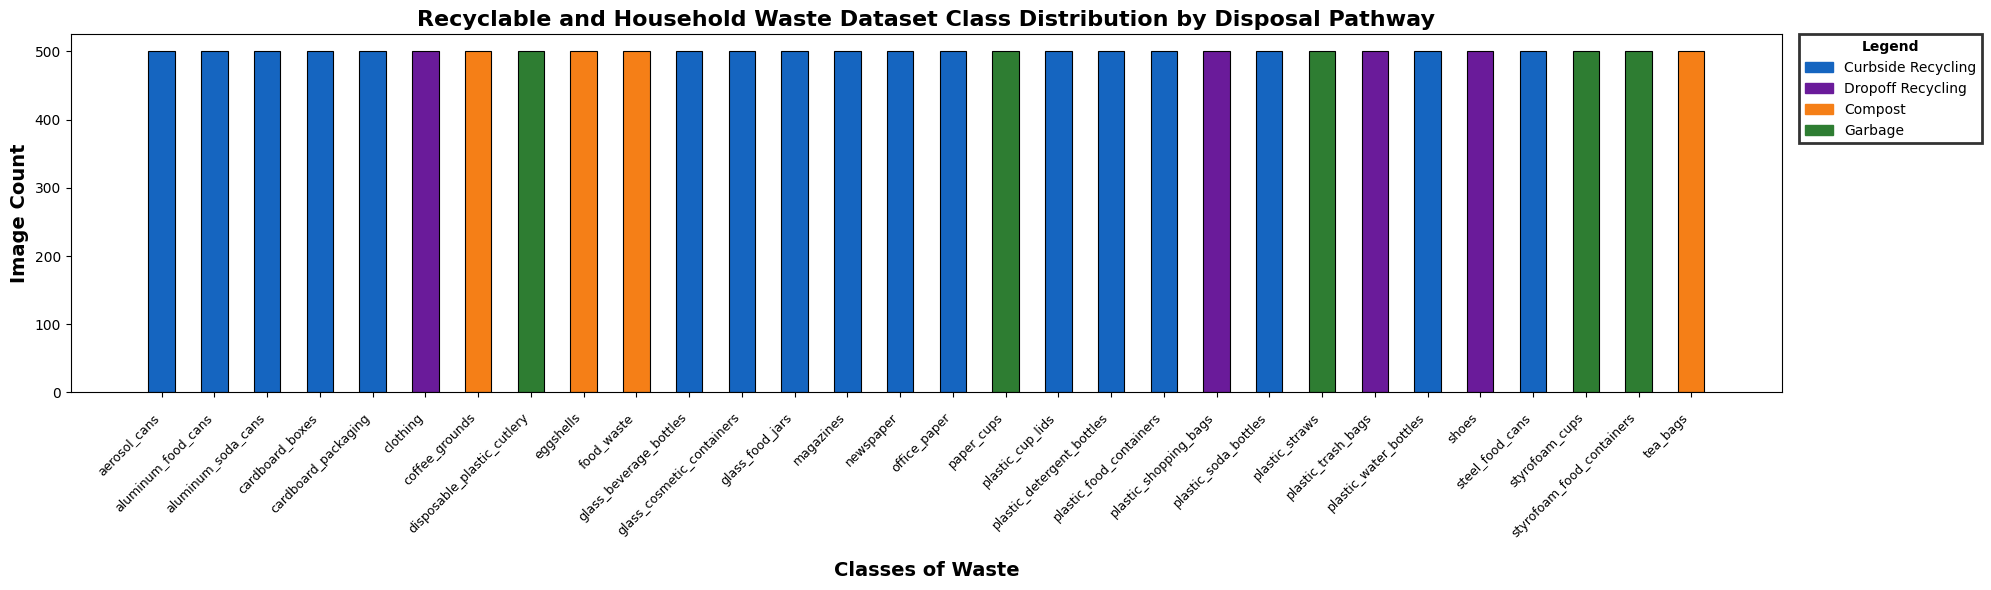

In [7]:
#==============-
# Bar Chart View
# ==============

# Initalize dictionary mapping disposal pathways to color for the legend
PATHWAY_COLORS = {
    'curbside_recycling': '#1565C0',
    'dropoff_recycling':  '#6A1B9A',
    'compost':            '#F57F17',
    'garbage':            '#2E7D32',
    'UNMAPPED':           '#B71C1C',
}

# Display class distribution in bar chart
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(df['class'], df['count'], width=0.5,
       color=[PATHWAY_COLORS.get(p, '#B71C1C') for p in df['pathway']],
       edgecolor='black', linewidth=0.8)

ax.set_xticks(range(len(df['class'])))
ax.set_xticklabels(df['class'], rotation=45, ha='right', fontsize=9)
ax.tick_params(axis='x', pad=10)

ax.set_xlabel('Classes of Waste', fontweight='bold', fontsize=14, labelpad=15)
ax.set_ylabel('Image Count', fontweight='bold', fontsize=14)
ax.set_title('Recyclable and Household Waste Dataset Class Distribution by Disposal Pathway', fontweight='bold', fontsize=16)

legend = ax.legend(
    handles=[mpatches.Patch(color=c, label=p.replace('_', ' ').title())
             for p, c in PATHWAY_COLORS.items() if p in df['pathway'].values],
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
    title='Legend',
    title_fontproperties={'weight': 'bold', 'size': 10},
    frameon=True,
    edgecolor='black',
    fancybox=False,
)
legend.get_frame().set_linewidth(2)

# Plot bar chart and save image to Waste Classification Dataset Audit
plt.tight_layout()
plt.savefig(DATASET_AUDIT_PATH / 'class_distribution_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

The dataset is well balanced: every class has roughly the same number of images and there are no missing or unmapped classes. Curbside recycling dominates by count because it covers 17 of the 30 classes, but no single class is starved.

### 1.5 Split Dataset into Train/Val/Test

Split the data into three directories on disk: **train (70%)**, **validation (15%)**, and **test (15%)**. Test images are also mirrored into per-subcategory folders (`test_default/` and `test_real_world/`) so section 2.8 can measure the domain gap between studio photos and real-world photos without re-running inference.

In [ ]:
# Clear old splits if they exist so we always start from scratch
if SPLITS_PATH.exists():
    shutil.rmtree(SPLITS_PATH)
    print("Cleared old splits")

# Walk every class and assign images to train, val, or test
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name

    images = [f for f in class_dir.rglob("*") if f.is_file()]
    if len(images) < 10:
        print(f"WARNING: {class_name} only has {len(images)} images, skipping")
        continue

    train_imgs, temp    = train_test_split(images, test_size=0.30, random_state=SEED)
    val_imgs, test_imgs = train_test_split(temp,   test_size=0.50, random_state=SEED)

    for split, imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
        split_dir = SPLITS_PATH / split / class_name
        split_dir.mkdir(parents=True, exist_ok=True)
        for img in imgs:
            # Prefix with the parent subfolder name to avoid filename collisions
            unique_name = f"{img.parent.name}_{img.name}"
            shutil.copy2(img, split_dir / unique_name)

            # Mirror test images into subcategory directories for the
            # default vs real-world evaluation in section 2.8
            if split == "test":
                subcat_dir = SPLITS_PATH / f"test_{img.parent.name}" / class_name
                subcat_dir.mkdir(parents=True, exist_ok=True)
                shutil.copy2(img, subcat_dir / unique_name)

print("Train/val/test splits written to disk")


## Step 2: Train Stage A, the Base Waste Classifier

### 2.1 Load Split Datasets

Load the three split directories into TensorFlow datasets. Each image is resized to 224 by 224 and grouped into batches of 32. `label_mode='categorical'` returns one-hot encoded labels because Stage A uses categorical cross-entropy.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

'''
Load split datasets from disk into TensorFlow datasets
Images are resized to 224x224 pixels and grouped into batches of 32
label_mode='categorical' returns one-hot labels required by CategoricalCrossentropy
'''

# Training Dataset - train
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Validatio Dataset - val
val_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset - test
test_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset of Default Images - test_default
test_default_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test_default'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset of Real World Images - test_real_world
test_real_world_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test_real_world'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names) # Sets number of neurons in Dense layer to 30
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {class_names}")

# Images are stored in memory after first epoch so they don't get re-read every time
train_ds           = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) # Images shuffled in train set
val_ds             = val_ds.cache().prefetch(buffer_size=AUTOTUNE)  # Loads next batch on CPU
test_ds            = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_default_ds    = test_default_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_real_world_ds = test_real_world_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 10500 files belonging to 30 classes.


I0000 00:00:1779579416.648448      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 2250 files belonging to 30 classes.
Found 2250 files belonging to 30 classes.
Found 1140 files belonging to 30 classes.
Found 1110 files belonging to 30 classes.
Number of classes: 30
Classes: ['aerosol_cans', 'aluminum_food_cans', 'aluminum_soda_cans', 'cardboard_boxes', 'cardboard_packaging', 'clothing', 'coffee_grounds', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'glass_food_jars', 'magazines', 'newspaper', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'plastic_water_bottles', 'shoes', 'steel_food_cans', 'styrofoam_cups', 'styrofoam_food_containers', 'tea_bags']


### 2.2 Apply Data Augmentation

Augmentation prevents the model from memorising specific orientations or lighting conditions. Each training image gets a small random rotation, zoom, translation, flip, brightness shift, and contrast shift before it reaches the backbone. The brightness and contrast shifts are kept modest (15%) because surface appearance is part of the signal for material classification.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=30/360),
    layers.RandomZoom(height_factor=0.2),
    layers.RandomTranslation(height_factor=0.15, width_factor=0.15),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.15),
], name="augmentation")


### 2.3 Build the Stage A Base Waste Classifier

Stage A is a transfer-learning model built on top of EfficientNetB0 with ImageNet weights. EfficientNetB0 is small enough to train and run quickly on a single GPU, but its ImageNet backbone has already learned the kind of low-level features (edges, colors, textures) that generalise to waste images.

The backbone is frozen while the classification head trains. The head takes the backbone's feature map, pools it down to a single vector, runs it through a dropout-protected 256-unit dense layer, and finishes with a softmax over the 30 classes.

| Layer | Output Shape | Trainable Params |
|-|-|-|
| Input | (None, 224, 224, 3) | 0 |
| Augmentation | (None, 224, 224, 3) | 0 |
| EfficientNetB0 (frozen) | (None, 7, 7, 1280) | 0 |
| GlobalAveragePooling2D | (None, 1280) | 0 |
| BatchNormalization | (None, 1280) | 5,120 |
| Dropout(0.5) | (None, 1280) | 0 |
| Dense(256, ReLU + L2) | (None, 256) | 327,936 |
| Dropout(0.3) | (None, 256) | 0 |
| Dense(30, softmax) | (None, 30) | 7,710 |

In [ ]:
def build_stage_a(num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)

    base_model = EfficientNetB0(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model._name = "stage_a_backbone"
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs, outputs, name="stage_a")
    return model, base_model


model_a, base_model = build_stage_a(NUM_CLASSES)
model_a.summary()


### 2.4 Define Training Callbacks

Three callbacks run during every training cycle to keep the run stable and to save the best weights without manual intervention.

| Callback | Monitors | What It Does |
|-|-|-|
| ModelCheckpoint | val_accuracy | Saves the best weights to disk whenever validation accuracy improves |
| EarlyStopping | val_accuracy | Stops training after 5 epochs with no improvement and rolls the model back to the best weights |
| ReduceLROnPlateau | val_loss | Halves the learning rate if validation loss stalls for 2 epochs, down to a floor of 1e-5 |

In [ ]:
checkpoint_cb = ModelCheckpoint(
    str(MODELS_PATH / "stage_a_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

early_stop_cb = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1,
)


### 2.5 Stage A Model Training

Train Stage A for up to 22 epochs. The backbone stays frozen the whole time; only the classification head learns. Adam with a learning rate of 1e-3 and categorical cross-entropy with 0.1 label smoothing are used. Wall-clock on Kaggle T4 is roughly **XX minutes**.

In [ ]:
print("Training Stage A")
base_model.trainable = False
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)

history_a = model_a.fit(
    train_ds,
    epochs=22,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb],
    verbose=1,
)


In [ ]:
print(f"Best Stage A checkpoint saved to: {MODELS_PATH / 'stage_a_best.keras'}")


In [ ]:
assert (MODELS_PATH / "stage_a_best.keras").exists(), "Stage A checkpoint missing"


### 2.6 Plot Training vs Validation Error Metrics

The accuracy and loss curves are a quick sanity check before evaluating on the test set. Train and validation curves should track each other closely; a widening gap means the model is overfitting.

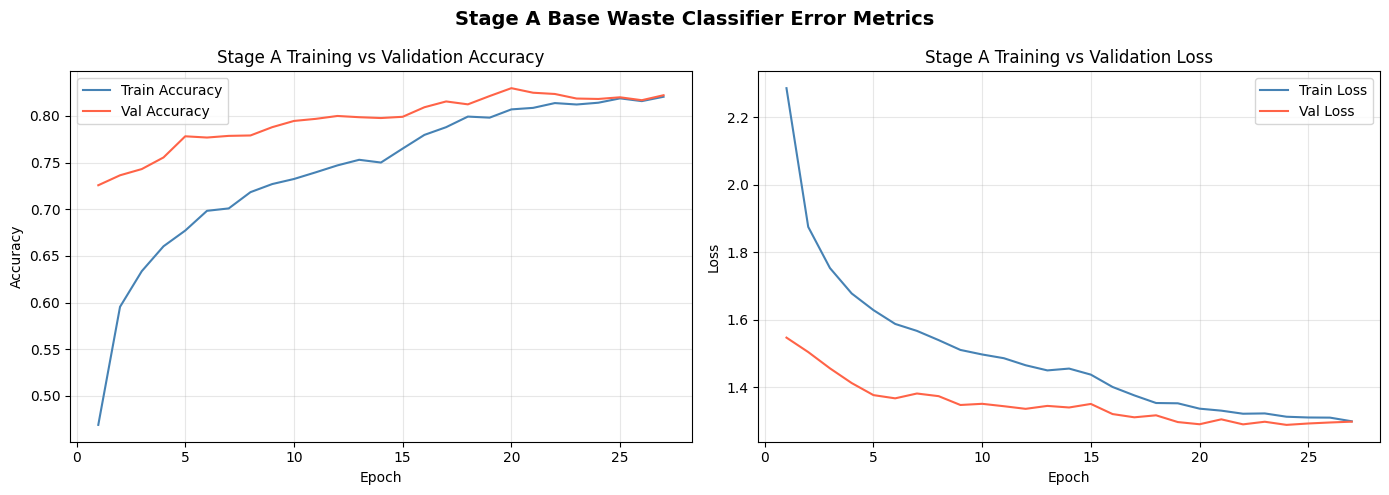

In [16]:
epochs = range(1, len(history_a.history['accuracy']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Stage A Accuracy
ax1.plot(epochs, history_a.history['accuracy'],     label='Train Accuracy', color='steelblue')
ax1.plot(epochs, history_a.history['val_accuracy'], label='Val Accuracy',   color='tomato')
ax1.set_title('Stage A Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Stage A Loss
ax2.plot(epochs, history_a.history['loss'],     label='Train Loss', color='steelblue')
ax2.plot(epochs, history_a.history['val_loss'], label='Val Loss',   color='tomato')
ax2.set_title('Stage A Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Stage A Base Waste Classifier Error Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.7 Evaluate Stage A on the Test Set

Run the best Stage A checkpoint on the held-out test set and report per-class accuracy, precision, recall, and F1. The classes are sorted by accuracy so the strongest and weakest performers are easy to spot.

In [17]:
# ==============-
# Table View
# ==============-

from sklearn.metrics import precision_score, recall_score, f1_score

best_model_a = tf.keras.models.load_model(MODELS_PATH / 'stage_a_best.keras')

# Run predictions on full test set
all_preds, all_labels = [], []
for images, labels in test_ds:
    preds = best_model_a.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot to integer class indices

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute per-class accuracy and sort descending
cm = confusion_matrix(all_labels, all_preds)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
sorted_indices     = np.argsort(per_class_accuracy)[::-1]

report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

# Print classification report organized by accuracy per class in descending order
print("Stage A Classification Report")
print("=" * 75)
print(f"{'Class':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("-" * 75)
for i in sorted_indices:
    name = class_names[i]
    acc  = per_class_accuracy[i]
    p    = report[name]['precision']
    r    = report[name]['recall']
    f1   = report[name]['f1-score']
    sup  = int(report[name]['support'])
    print(f"{name:<35} {acc:>9.4f} {p:>10.4f} {r:>8.4f} {f1:>8.4f} {sup:>9}")
print("-" * 75)
print(f"{'macro avg':<35} {np.mean(per_class_accuracy):>9.4f} {report['macro avg']['precision']:>10.4f} {report['macro avg']['recall']:>8.4f} {report['macro avg']['f1-score']:>8.4f} {int(report['macro avg']['support']):>9}")

Stage A Classification Report
Class                                Accuracy  Precision   Recall       F1   Support
---------------------------------------------------------------------------
shoes                                  0.9600     0.9600   0.9600   0.9600        75
coffee_grounds                         0.9600     0.9474   0.9600   0.9536        75
eggshells                              0.9333     0.8642   0.9333   0.8974        75
food_waste                             0.9067     0.8947   0.9067   0.9007        75
magazines                              0.9067     0.8193   0.9067   0.8608        75
plastic_trash_bags                     0.8933     0.9178   0.8933   0.9054        75
plastic_straws                         0.8933     0.8590   0.8933   0.8758        75
aerosol_cans                           0.8933     0.8590   0.8933   0.8758        75
glass_food_jars                        0.8933     0.8072   0.8933   0.8481        75
styrofoam_food_containers              0.880

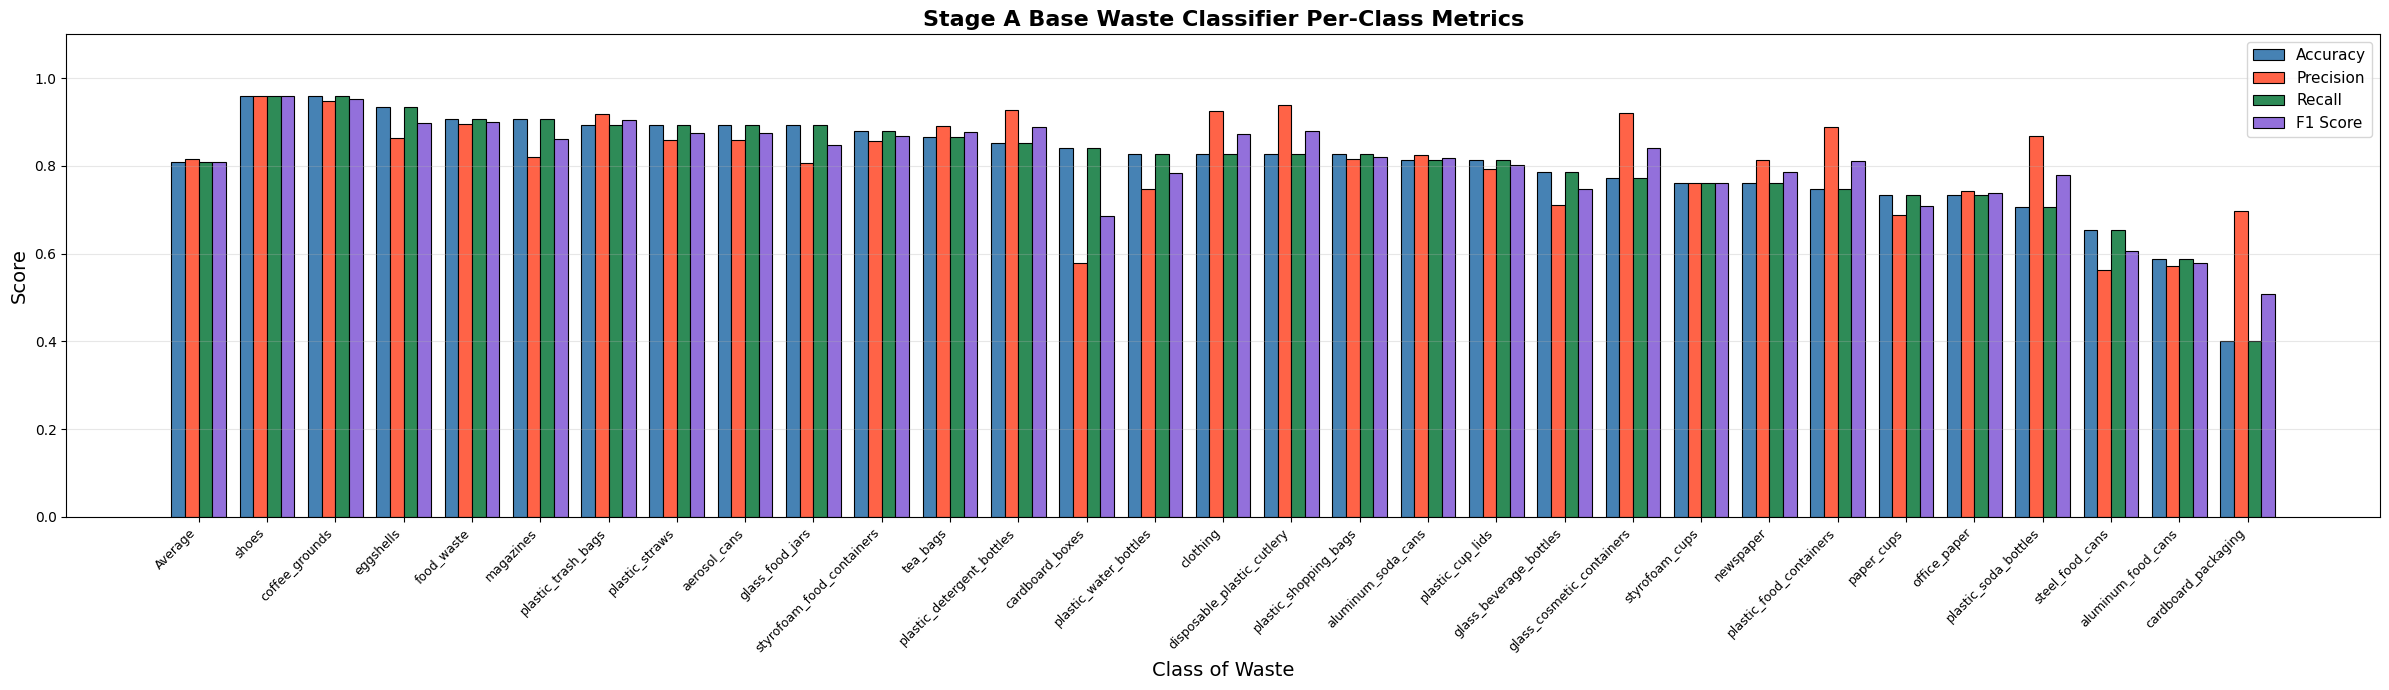


Overall Metrics
Accuracy:  0.8084
Precision: 0.8151
Recall:    0.8084
F1 Score:  0.8081


In [18]:
# ==============-
# Bar Chart View
# ==============-

# Calculates Per-Class Metrics
per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1        = f1_score(all_labels, all_preds, average=None, zero_division=0)

# Calculates average accuracy, precision, recall and F1
avg_accuracy  = np.mean(per_class_accuracy)
avg_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
avg_recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)
avg_f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)

# Sort classes by descending accuracy, average bar first
sorted_labels    = ['Average'] + [class_names[i] for i in sorted_indices]
sorted_accuracy  = [avg_accuracy]  + [per_class_accuracy[i]  for i in sorted_indices]
sorted_precision = [avg_precision] + [per_class_precision[i] for i in sorted_indices]
sorted_recall    = [avg_recall]    + [per_class_recall[i]    for i in sorted_indices]
sorted_f1        = [avg_f1]        + [per_class_f1[i]        for i in sorted_indices]

x     = np.arange(len(sorted_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(24, 7))
ax.bar(x - 1.5*width, sorted_accuracy,  width, label='Accuracy',  color='steelblue',   edgecolor='black', linewidth=0.8)
ax.bar(x - 0.5*width, sorted_precision, width, label='Precision', color='tomato',       edgecolor='black', linewidth=0.8)
ax.bar(x + 0.5*width, sorted_recall,    width, label='Recall',    color='seagreen',     edgecolor='black', linewidth=0.8)
ax.bar(x + 1.5*width, sorted_f1,        width, label='F1 Score',  color='mediumpurple', edgecolor='black', linewidth=0.8)

ax.set_title('Stage A Base Waste Classifier Per-Class Metrics', fontsize=16, fontweight='bold')
ax.set_xlabel('Class of Waste', fontsize=14,)
ax.set_ylabel('Score', fontsize=14,)
ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall Metrics")
print(f"{'='*40}")
print(f"Accuracy:  {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall:    {avg_recall:.4f}")
print(f"F1 Score:  {avg_f1:.4f}")

Stage A reaches an overall test accuracy of **XX.X%** with an average F1 of **XX.X%**. Strong performers (>90% F1) tend to be visually distinctive items such as **XX**, **XX**, and **XX**. Weaker performers (<70% F1) are typically items that look like other classes, such as **XX** vs **XX** or **XX** vs **XX**. Section 2.10 shows what happens when accuracy is measured at the pathway level instead of the class level.

### 2.8 Default vs Real World Test Set Evaluation

Each class has both `default` photos (clean backgrounds, product-style) and `real_world` photos (in-the-wild, varied lighting and backgrounds). Running Stage A on each subcategory separately measures how well the model generalises beyond studio conditions.

Default    Overall Accuracy: 0.8342
Real World Overall Accuracy: 0.7820
Domain Gap:                 +0.0522

Class                                 Default  Real World      Gap
------------------------------------------------------------------
cardboard_packaging                    0.3684      0.4324  -0.0640
aluminum_food_cans                     0.6579      0.5135  +0.1444
styrofoam_cups                         0.9211      0.5946  +0.3265
newspaper                              0.8947      0.6216  +0.2731
plastic_soda_bottles                   0.7632      0.6486  +0.1145
office_paper                           0.7895      0.6757  +0.1138
paper_cups                             0.7632      0.7027  +0.0605
plastic_food_containers                0.7895      0.7027  +0.0868
plastic_water_bottles                  0.9211      0.7297  +0.1913
plastic_cup_lids                       0.8684      0.7568  +0.1117
steel_food_cans                        0.5526      0.7568  -0.2041
plastic_shopping_bag

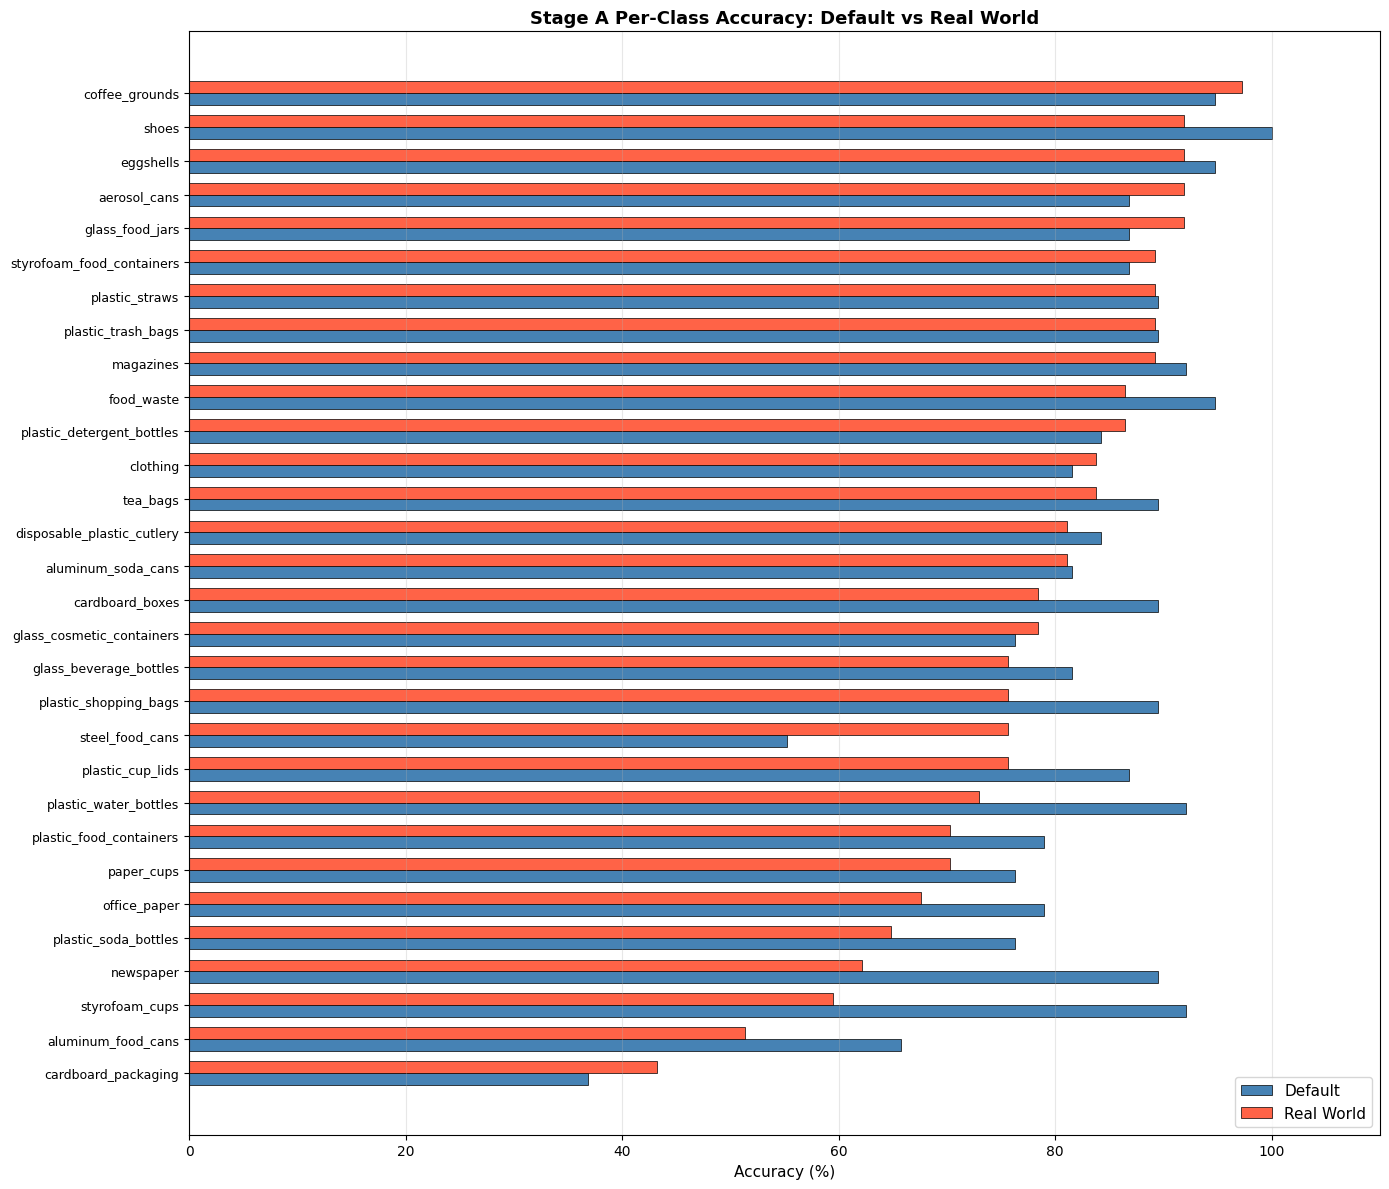

In [19]:
def evaluate_subcategory(model, dataset):
    preds, labels = [], []
    for images, label_batch in dataset:
        batch_preds = model.predict(images, verbose=0)
        preds.extend(np.argmax(batch_preds, axis=1))
        labels.extend(np.argmax(label_batch.numpy(), axis=1))  # Convert one-hot to integer class indices
    return np.array(preds), np.array(labels)

preds_default, labels_default = evaluate_subcategory(best_model_a, test_default_ds)
preds_real,    labels_real    = evaluate_subcategory(best_model_a, test_real_world_ds)

# Compute per-class accuracy for each subcategory
def per_class_acc(labels, preds):
    cm_sub  = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    row_sum = cm_sub.sum(axis=1)
    row_sum[row_sum == 0] = 1  # Avoid division by zero for any empty class
    return cm_sub.diagonal() / row_sum

acc_default = per_class_acc(labels_default, preds_default)
acc_real    = per_class_acc(labels_real,    preds_real)

# Print overall accuracy for each subcategory
print(f"Default    Overall Accuracy: {acc_default.mean():.4f}")
print(f"Real World Overall Accuracy: {acc_real.mean():.4f}")
print(f"Domain Gap:                 {acc_default.mean() - acc_real.mean():+.4f}")

# Print per-class comparison table sorted by real_world accuracy ascending
sorted_by_real = np.argsort(acc_real)
print(f"\n{'Class':<35} {'Default':>9} {'Real World':>11} {'Gap':>8}")
print("-" * 66)
for i in sorted_by_real:
    gap = acc_default[i] - acc_real[i]
    print(f"{class_names[i]:<35} {acc_default[i]:>9.4f} {acc_real[i]:>11.4f} {gap:>+8.4f}")

# Sort ascending so highest real_world accuracy is at the top of the chart
sort_idx       = np.argsort(acc_real)
sorted_names   = [class_names[i] for i in sort_idx]
sorted_default = [acc_default[i] * 100 for i in sort_idx]
sorted_real    = [acc_real[i]    * 100 for i in sort_idx]

y      = np.arange(len(sorted_names))
height = 0.35

fig, ax = plt.subplots(figsize=(14, 12))
ax.barh(y - height/2, sorted_default, height, label='Default',    color='steelblue', edgecolor='black', linewidth=0.5)
ax.barh(y + height/2, sorted_real,    height, label='Real World', color='tomato',    edgecolor='black', linewidth=0.5)

ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Stage A Per-Class Accuracy: Default vs Real World', fontweight='bold', fontsize=13)
ax.set_xlim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_default_vs_real_world.png', dpi=150, bbox_inches='tight')
plt.show()

Stage A reaches **XX.X%** accuracy on the default subcategory and **XX.X%** on the real-world subcategory, for a domain gap of **XX.X percentage points**. A gap here is expected; in-the-wild photos have backgrounds, occlusion, and lighting variation that augmentation alone cannot fully simulate. The Vercel dashboard inputs are real-world photos from a phone camera, so this number is the more honest predictor of deployed performance.

### 2.9 Confusion Matrices

Two confusion matrices help diagnose where Stage A fails:

1. A **30-class confusion matrix** that shows which classes the model confuses with which other classes. Most off-diagonal mass is expected to be inside disposal-pathway clusters (one type of paper confused for another type of paper).
2. A **disposal-pathway confusion matrix** that collapses the 30-class predictions down to the four pathways. This is the matrix that matters for the actual user-facing decision: it shows whether the model picks the right bin, even when it gets the specific class slightly wrong.

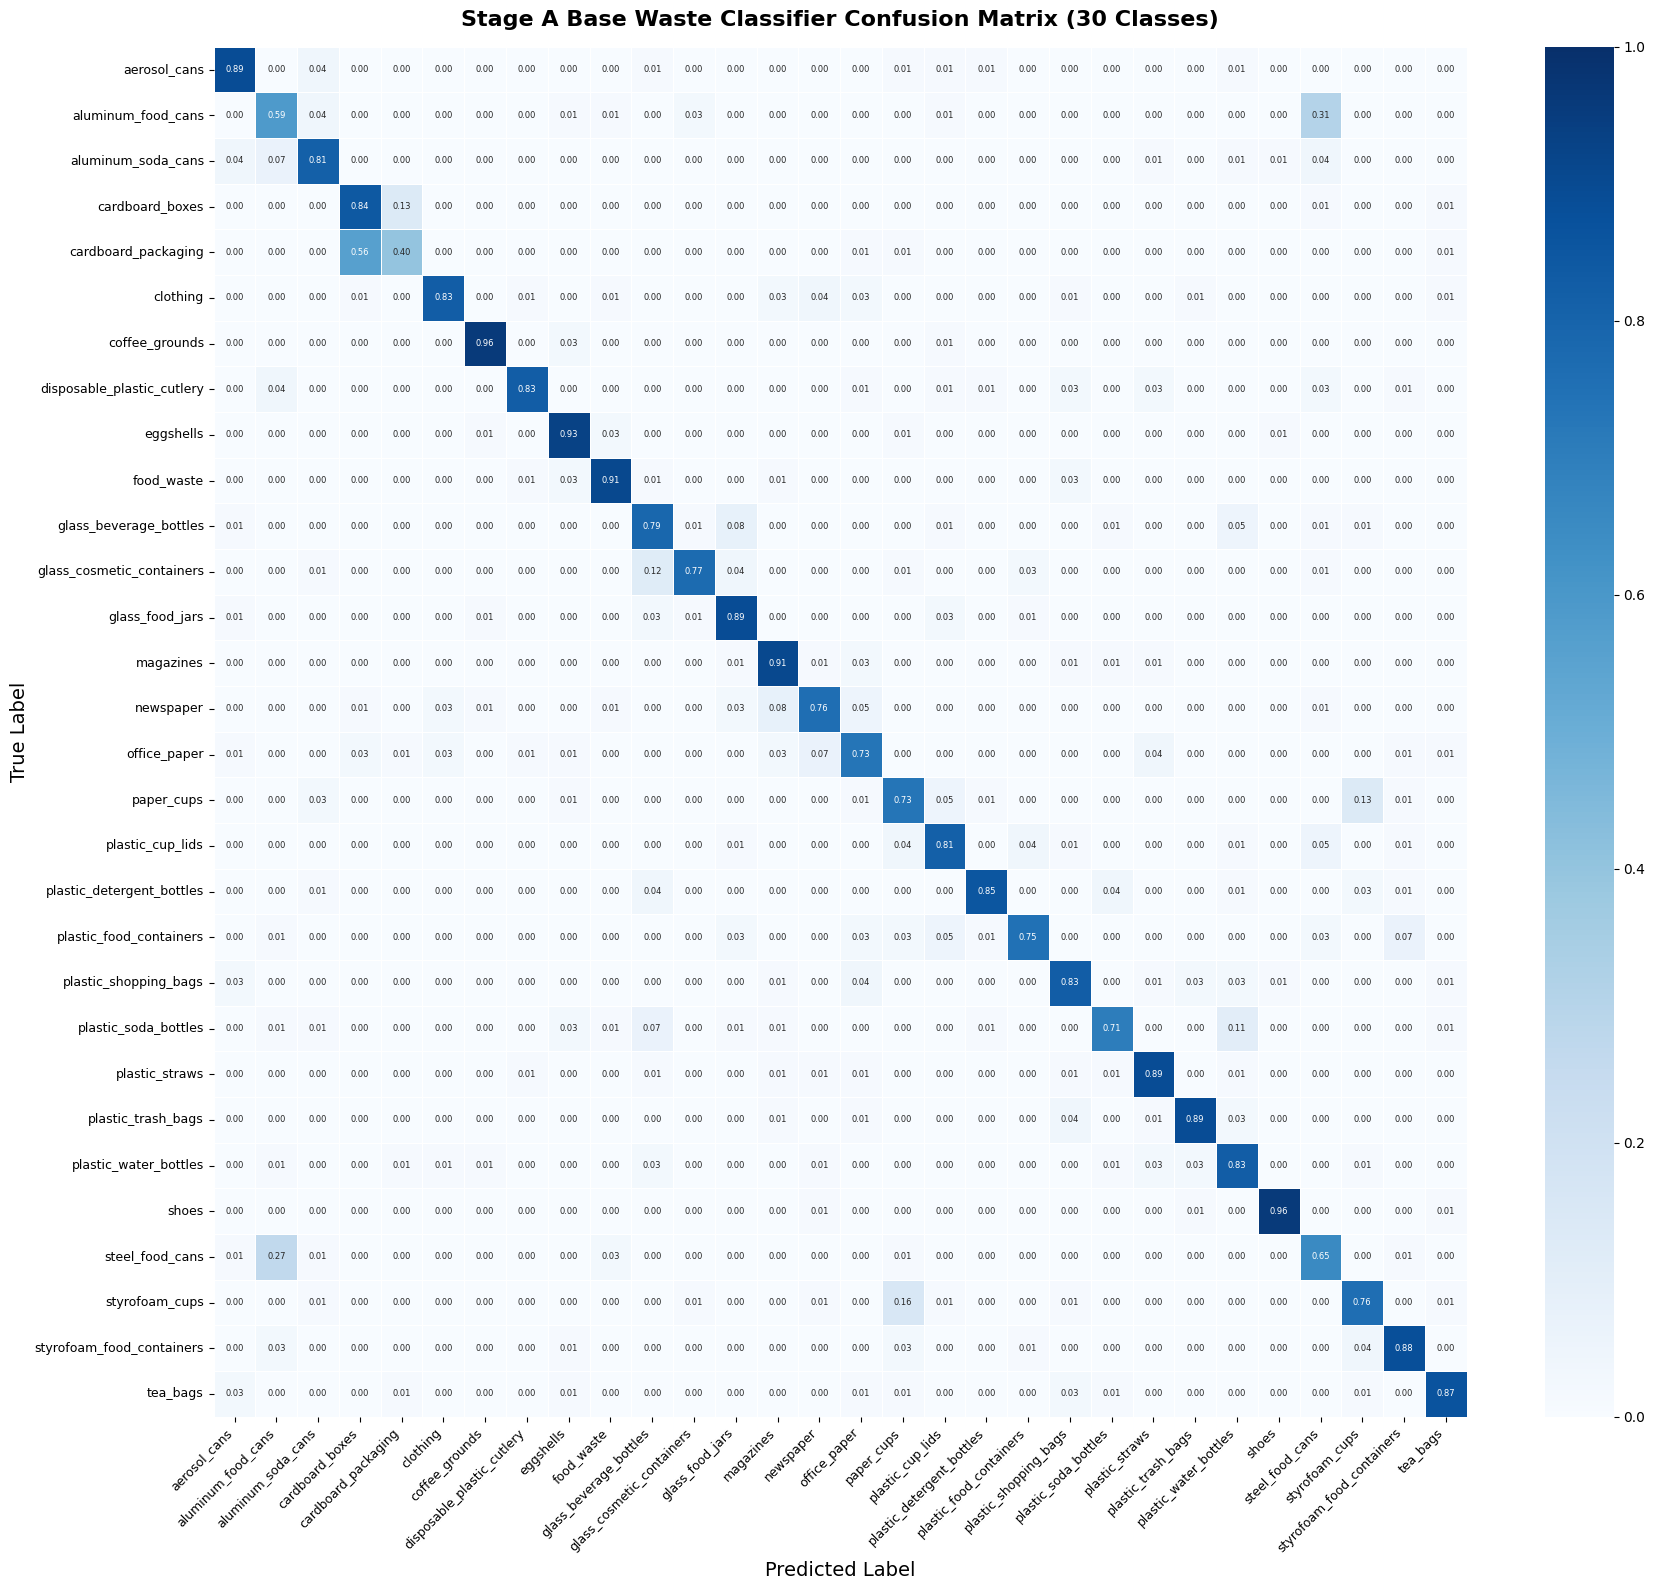

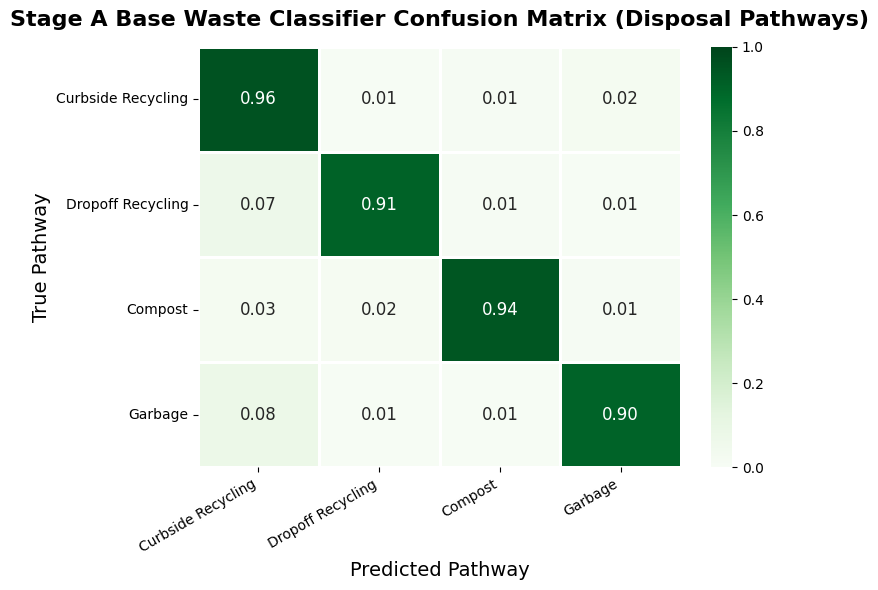

In [20]:
# ============================
# Class-level Confusion Matrix
# ============================

# Normalize class confusion matrix so each row sums to 1
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 6},
    vmin=0,
    vmax=1
)

# Print Class-level Confuson Matrix
ax.set_title('Stage A Base Waste Classifier Confusion Matrix (30 Classes)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_confusion_matrix_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================-
# Disposal Pathway Confusion Matrix
# ================================-

# Build disposal pathway confusion matrix
PATHWAY_ORDER  = ['curbside_recycling', 'dropoff_recycling', 'compost', 'garbage']
PATHWAY_LABELS = [p.replace('_', ' ').title() for p in PATHWAY_ORDER]

pathway_true = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in all_labels]
pathway_pred = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in all_preds]

cm_pathway      = confusion_matrix(pathway_true, pathway_pred, labels=PATHWAY_ORDER)
cm_pathway_norm = cm_pathway.astype(float) / cm_pathway.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_pathway_norm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=PATHWAY_LABELS,
    yticklabels=PATHWAY_LABELS,
    ax=ax,
    linewidths=1,
    annot_kws={'size': 12},
    vmin=0,
    vmax=1
)

# Print Disposal Pathway Confusion Matrix
ax.set_title('Stage A Base Waste Classifier Confusion Matrix (Disposal Pathways)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Pathway', fontsize=14)
ax.set_ylabel('True Pathway', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_confusion_matrix_pathways.png', dpi=150, bbox_inches='tight')
plt.show()

The pathway-level matrix is significantly cleaner than the class-level matrix. Most class-level mistakes happen between items that share a disposal pathway (different types of paper, different metal cans), so they do not affect the final decision. This is exactly what motivates the adjusted-accuracy chart in section 2.10.

### 2.10 Plot Adjusted Accuracy Bar Chart

Adjusted accuracy counts a prediction as correct if the predicted class and the true class map to the same disposal pathway, even when they are different classes. It is the metric that matches what the user actually cares about: did the item end up in the right bin?

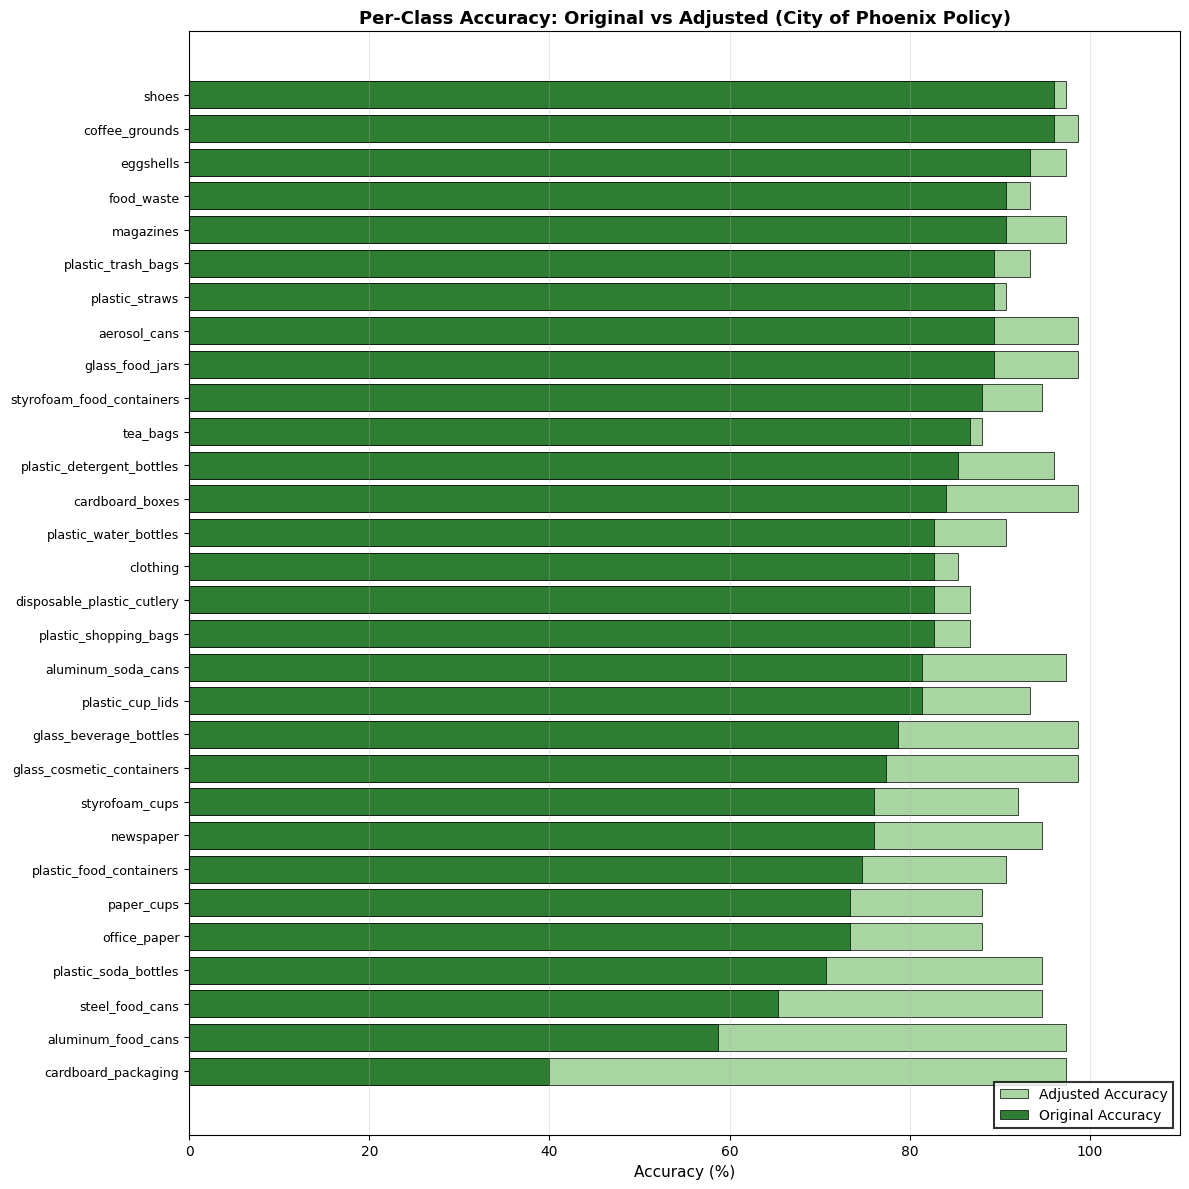

Original Accuracy: 0.8084
Adjusted Accuracy: 0.9391
Pathway Gain:      +0.1307


In [21]:
# Compute adjusted accuracy: correct if predicted class shares a disposal pathway with the true class
adjusted_correct = np.zeros(NUM_CLASSES)
class_counts     = np.zeros(NUM_CLASSES)

for true_idx, pred_idx in zip(all_labels, all_preds):
    true_pathway = DISPOSAL_MAP.get(class_names[true_idx], 'UNMAPPED')
    pred_pathway = DISPOSAL_MAP.get(class_names[pred_idx], 'UNMAPPED')
    class_counts[true_idx] += 1
    if true_pathway == pred_pathway:
        adjusted_correct[true_idx] += 1

adj_acc_per_class = adjusted_correct / class_counts

# Sort by original accuracy ascending so highest is at top of chart
sort_idx     = np.argsort(per_class_accuracy)
sorted_names = [class_names[i] for i in sort_idx]
sorted_orig  = [per_class_accuracy[i] * 100 for i in sort_idx]
sorted_adj   = [adj_acc_per_class[i]  * 100 for i in sort_idx]

y = np.arange(len(sorted_names))

fig, ax = plt.subplots(figsize=(12, 12))

# Draw adjusted accuracy bars first so original bars sit on top
ax.barh(y, sorted_adj,  color='#A8D5A2', label='Adjusted Accuracy', edgecolor='black', linewidth=0.5)
ax.barh(y, sorted_orig, color='#2E7D32', label='Original Accuracy',  edgecolor='black', linewidth=0.5)

ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy: Original vs Adjusted (City of Phoenix Policy)', fontweight='bold', fontsize=13)
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)

legend = ax.legend(
    loc='lower right',
    frameon=True,
    edgecolor='black',
    fancybox=False,
    fontsize=10
)
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_adjusted_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Print overall accuracy comparison
overall_orig = per_class_accuracy.mean()
overall_adj  = adjusted_correct.sum() / class_counts.sum()
print(f"Original Accuracy: {overall_orig:.4f}")
print(f"Adjusted Accuracy: {overall_adj:.4f}")
print(f"Pathway Gain:      {overall_adj - overall_orig:+.4f}")

Adjusted accuracy is **XX percentage points** higher than raw class accuracy, confirming that most of Stage A's residual errors are within-pathway confusions that do not affect the deployed decision.

## Step 3: Prepare Synthetic Recyclable Contamination Dataset

Stage B needs labeled examples of contaminated recyclables, but no public dataset has that at the scale this project needs. Step 3 builds one synthetically: take clean recyclable photos, segment the object, paste random contamination textures (food residue, grease, mold, paint, etc.) onto the object surface, and save the result alongside the clean original. Each source image produces 1 clean copy and 8 contaminated copies (one per texture type), so the final dataset has a known 1:8 clean-to-contaminated ratio.

### 3.1 Install Dependencies

Step 3 needs the rembg package (for object segmentation) and pillow-avif-plugin (for the texture files that ship as AVIF). Both are missing from Kaggle\'s base TensorFlow image, so install them here.

In [ ]:
!pip install -q "rembg[gpu]" pillow-avif-plugin


### 3.2 Import Libraries

Import the few additional modules Step 3 uses on top of what Step 0 already imported.

In [23]:
import io
import math

from rembg import remove, new_session
from scipy import ndimage

from PIL import ImageFilter
from tqdm import tqdm

### 3.3 Initialise the rembg Session

Load the U2-Net background-removal model once at the start of Step 3 and reuse the session for every image. Reusing the session avoids re-loading the model weights for every call.

In [24]:
REMBG_SESSION = new_session('u2netp')
print("U2-Net session initialised")

  0%|                                              | 0.00/4.57M [00:00<?, ?B/s]

U2-Net session initialised


### 3.4 Configure Paths and Constants

Bind the texture dataset path and the Stage B output paths. `MAX_IMAGES = 1000` caps how many source images get processed; with 9 outputs per source the full Stage B dataset is 9,000 images. `CONTAMINATION_LEVELS` maps human-readable severity labels to a patch count (more patches means heavier contamination).

In [ ]:
TEXTURE_PATH  = Path("/kaggle/input/datasets/ragbag84/waste-contamination-textures-dataset/Contamination Textures Dataset/textures")
STAGE_B_PATH  = Path("/kaggle/working/Stage B Dataset")
TEXTURE_CACHE = Path("/kaggle/working/texture_cache")
DATASET_ROOT  = Path("/kaggle/working/Synthetic Recyclable Contamination Dataset")

# Cap source images per Stage B run. 1000 sources times 9 outputs per source
# gives a 9000-image dataset that trains in roughly 25 minutes on Kaggle.
MAX_IMAGES = 1000

CONTAMINATION_LEVELS = {
    "light":  1,
    "medium": 2,
    "heavy":  3,
}

# Recyclable classes only (the only pathways where contamination is a deciding factor)
RECYCLABLE_CLASSES = [
    cls for cls, pathway in DISPOSAL_MAP.items()
    if pathway in ("curbside_recycling", "dropoff_recycling")
]


### 3.5 Build the Contamination Texture Pool

#### 3.5.1 Discover Contaminant Types and Texture Images

In [26]:
def build_texture_pool(texture_path: Path) -> dict:
    pool = {}
    for contaminant_dir in sorted(texture_path.iterdir()):
        if not contaminant_dir.is_dir():
            continue
        textures = sorted(
            f for f in contaminant_dir.iterdir()
            if f.suffix.lower() == '.png'
            and '_nobg' not in f.stem
        )
        if textures:
            pool[contaminant_dir.name] = textures
    return pool

texture_pool = build_texture_pool(TEXTURE_PATH)

print(f"Discovered {len(texture_pool)} contaminant types")
for contaminant, textures in texture_pool.items():
    print(f"  {contaminant:<25} {len(textures)} images")

Discovered 8 contaminant types
  coffee_stains             5 images
  condiment_residue         5 images
  dirt                      5 images
  food_residue              5 images
  grease                    5 images
  mold                      5 images
  paint                     5 images
  wet_paper_pulp            5 images


#### 3.5.2 Display Texture Pool Summary

In [27]:
total = sum(len(v) for v in texture_pool.values())
print(f"Contamination Texture Library")
print(f"{'='*50}")
for contaminant, textures in texture_pool.items():
    print(f"\n  {contaminant}")
    for t in textures:
        print(f"    {t.name}")
print(f"\n{'='*50}")
print(f"Total: {len(texture_pool)} types, {total} images")

Contamination Texture Library

  coffee_stains
    coffee_stain_1.png
    coffee_stain_2.png
    coffee_stain_3.png
    coffee_stain_4.png
    coffee_stain_5.png

  condiment_residue
    condiment_residue_1.png
    condiment_residue_2.png
    condiment_residue_3.png
    condiment_residue_4.png
    condiment_residue_5.png

  dirt
    dirt_1.png
    dirt_2.png
    dirt_3.png
    dirt_4.png
    dirt_5.png

  food_residue
    food_residue_1.png
    food_residue_2.png
    food_residue_3.png
    food_residue_4.png
    food_residue_5.png

  grease
    grease_1.png
    grease_2.png
    grease_3.png
    grease_4.png
    grease_5.png

  mold
    mold_1.png
    mold_2.png
    mold_3.png
    mold_4.png
    mold_5.png

  paint
    paint_stain_1.png
    paint_stain_2.png
    paint_stain_3.png
    paint_stain_4.png
    paint_stain_5.png

  wet_paper_pulp
    wet_paper_pulp_1.png
    wet_paper_pulp_2.png
    wet_paper_pulp_3.png
    wet_paper_pulp_4.png
    wet_paper_pulp_5.png

Total: 8 types, 40 ima

The pool contains exactly 8 contaminant types and around 40 texture images in total. The 8 types become the contamination class labels for Stage B in Step 4.

### 3.6 Define Image Processing Functions

Three helpers do the heavy lifting in Step 3.8\'s generation loop. They are defined separately so each one can be tested or swapped independently.

#### 3.6.1 Object Segmentation

U2-Net produces a soft alpha mask for the object in the image. A small morphological closing fills any holes left by transparent or reflective surfaces, and a Gaussian blur feathers the edges so the contamination patch fades naturally at the object boundary.

In [28]:
def get_object_mask(img: np.ndarray) -> np.ndarray:
    buf = io.BytesIO()
    Image.fromarray(img).save(buf, format='PNG')
    output = remove(buf.getvalue(), session=REMBG_SESSION)
    alpha  = np.array(Image.open(io.BytesIO(output)).convert('RGBA'))[:, :, 3]
    alpha  = alpha.astype(np.float32) / 255.0
    # Fill small interior holes left by transparent or reflective surfaces
    binary = ndimage.binary_closing(
        alpha > 0.5, structure=np.ones((5, 5))
    ).astype(np.float32)
    # Feather edges so composited contamination fades at the object boundary
    return ndimage.gaussian_filter(binary, sigma=2)

#### 3.6.2 Texture Loading

Load a texture image and cache it with its background removed. The cache lives under `/kaggle/working` because `/kaggle/input` is read-only. If a PNG texture already has transparency, skip the rembg call.

In [29]:
def load_texture(texture_path: Path) -> np.ndarray:
    # Cache lives in /kaggle/working since /kaggle/input is read-only
    cache_path = TEXTURE_CACHE / texture_path.parent.name / (texture_path.stem + '_nobg.png')
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists():
        return np.array(Image.open(cache_path).convert('RGBA'))

    ext           = texture_path.suffix.lower()
    needs_removal = True

    if ext == '.png':
        rgba = np.array(Image.open(texture_path).convert('RGBA'))
        # If the alpha channel already has transparency, use it directly
        if rgba[:, :, 3].min() < 255:
            needs_removal = False

    if needs_removal:
        with open(texture_path, 'rb') as f:
            output = remove(f.read(), session=REMBG_SESSION)
        rgba = np.array(Image.open(io.BytesIO(output)).convert('RGBA'))

    Image.fromarray(rgba).save(cache_path)
    return rgba

#### 3.6.3 Texture Patch Application

Paste a texture patch onto a random point inside the object mask. The texture is randomly rotated, scaled, flipped, and alpha-blended so every contaminated copy looks different even with the same texture file.

In [30]:
def apply_texture_patch(
    base_img:     np.ndarray,
    texture_rgba: np.ndarray,
    object_mask:  np.ndarray,
    alpha:        float = 0.6,
) -> np.ndarray:
    H, W = base_img.shape[:2]

    # Sample a random anchor point from within the object region
    obj_ys, obj_xs = np.where(object_mask > 0.3)
    if len(obj_ys) == 0:
        return base_img
    idx = random.randint(0, len(obj_ys) - 1)
    cy, cx = int(obj_ys[idx]), int(obj_xs[idx])

    # Augment the texture
    tex = Image.fromarray(texture_rgba, 'RGBA')
    tex = tex.rotate(random.uniform(0, 360), expand=True)
    scale = random.uniform(0.25, 0.60)
    tex = tex.resize((max(1, int(W * scale)), max(1, int(H * scale))), Image.LANCZOS)
    if random.random() > 0.5:
        tex = tex.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() > 0.5:
        tex = tex.transpose(Image.FLIP_TOP_BOTTOM)

    tex_arr = np.array(tex)
    th, tw  = tex_arr.shape[:2]

    # Compute placement coordinates centered on the anchor
    x1, y1 = cx - tw // 2, cy - th // 2
    x2, y2 = x1 + tw, y1 + th

    # Clip to image bounds
    ix1, iy1 = max(0, x1), max(0, y1)
    ix2, iy2 = min(W, x2), min(H, y2)

    if ix2 <= ix1 or iy2 <= iy1:
        return base_img

    sx1 = ix1 - x1
    sy1 = iy1 - y1
    sx2 = sx1 + (ix2 - ix1)
    sy2 = sy1 + (iy2 - iy1)
    tex_slice = tex_arr[sy1:sy2, sx1:sx2]

    # Three-way weight: texture alpha x object mask x opacity scalar
    tex_a  = tex_slice[:, :, 3].astype(np.float32) / 255.0
    obj_a  = object_mask[iy1:iy2, ix1:ix2]
    weight = tex_a * obj_a * alpha

    # Composite
    result  = base_img.astype(np.float32)
    region  = result[iy1:iy2, ix1:ix2]
    tex_rgb = tex_slice[:, :, :3].astype(np.float32)
    result[iy1:iy2, ix1:ix2] = (
        region * (1 - weight[..., np.newaxis]) + tex_rgb * weight[..., np.newaxis]
    )
    return np.clip(result, 0, 255).astype(np.uint8)

### 3.7 Build the Output Directory Structure

Wipe any old Stage B dataset and recreate the directory tree. `clean/{class}/` holds the unmodified copies; `contaminated/{contaminant}/{level}/` holds the synthetically contaminated copies grouped by texture type and severity.

In [31]:
if STAGE_B_PATH.exists():
    shutil.rmtree(STAGE_B_PATH)
    print("Cleared existing Stage B Dataset directory")

for contaminant in texture_pool:
    for level in CONTAMINATION_LEVELS:
        (STAGE_B_PATH / 'contaminated' / contaminant / level).mkdir(parents=True, exist_ok=True)

print("Output directory structure created")
print(f"  {STAGE_B_PATH / 'contaminated'}")

Output directory structure created
  /kaggle/working/Stage B Dataset/contaminated


### 3.8 Run the Generation Pipeline

Stratified-sample 1,000 source images across every recyclable class proportional to its size. For each source image: save 1 clean copy, run object segmentation once, then loop the 8 texture types and produce 1 contaminated copy per type with a randomly chosen severity. Total output is 9,000 images. Wall-clock on Kaggle T4 is roughly **XX minutes**.

In [32]:
# Clear texture cache so load_texture rebuilds it with background removal applied
import shutil
if TEXTURE_CACHE.exists():
    shutil.rmtree(TEXTURE_CACHE)
    print(f"Cleared texture cache: {TEXTURE_CACHE}")
else:
    print("No cache to clear.")

No cache to clear.


In [ ]:
records           = []
contaminant_types = sorted(texture_pool.keys())
assert len(contaminant_types) == 8, \
    f"Expected 8 contaminant types, found {len(contaminant_types)}: {contaminant_types}"

# Collect every source image grouped by class so we can stratified-sample
images_by_class = {}
for cls in RECYCLABLE_CLASSES:
    cls_dir = DATASET_PATH / cls
    if not cls_dir.exists():
        print(f"WARNING: {cls} not found, skipping")
        continue
    images_by_class[cls] = sorted(p for p in cls_dir.rglob("*") if p.is_file())

# Allocate the 1000-image quota proportional to each class's share of the pool
total_available = sum(len(v) for v in images_by_class.values())
target_total    = min(MAX_IMAGES, total_available)
rng             = np.random.default_rng(SEED)

selected = []
for cls, files in images_by_class.items():
    share = round(target_total * len(files) / total_available)
    share = min(share, len(files))
    if share == 0:
        continue
    idx = rng.choice(len(files), size=share, replace=False)
    selected.extend((cls, files[i]) for i in idx)

# Trim or top up to hit target_total exactly (rounding can drift by a couple)
if len(selected) > target_total:
    selected = selected[:target_total]
elif len(selected) < target_total:
    needed = target_total - len(selected)
    leftover = [(cls, f) for cls, files in images_by_class.items() for f in files
                if (cls, f) not in set(selected)]
    selected.extend(rng.choice(leftover, size=min(needed, len(leftover)), replace=False).tolist())

random.Random(SEED).shuffle(selected)
n_sources = len(selected)
print(f"Sources : {n_sources:,}")
print(f"Expected outputs: {n_sources * 9:,} ({n_sources:,} clean + {n_sources * 8:,} contaminated)")
print(f"Textures: {contaminant_types}")
print()

# ====- Generation loop ====-
for class_name, img_path in tqdm(selected, desc="Generating"):
    source_stem = f"{img_path.parent.name}_{img_path.stem}"

    base_img = np.array(
        Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    )

    # Save the clean copy
    clean_dir  = STAGE_B_PATH / "clean" / class_name
    clean_dir.mkdir(parents=True, exist_ok=True)
    clean_path = clean_dir / f"{source_stem}.png"
    Image.fromarray(base_img).save(clean_path, format="PNG")

    records.append({
        "image_path":   str(clean_path),
        "label":        "clean",
        "subgroup":     "none",
        "level":        "none",
        "source_class": class_name,
        "source_stem":  source_stem,
    })

    # rembg is the expensive call; run it once per source then reuse the mask
    mask = get_object_mask(base_img)

    # One contaminated copy for every texture type, severity picked randomly
    for contaminant_type in contaminant_types:
        textures = texture_pool[contaminant_type]
        level    = random.choice(list(CONTAMINATION_LEVELS.keys()))
        n_patches = CONTAMINATION_LEVELS[level]

        result_img = base_img.copy()
        for _ in range(n_patches):
            tex_path = random.choice(textures)
            texture  = load_texture(tex_path)
            alpha    = random.uniform(0.45, 0.75)
            result_img = apply_texture_patch(result_img, texture, mask, alpha=alpha)

        cont_dir  = STAGE_B_PATH / "contaminated" / contaminant_type / level
        cont_dir.mkdir(parents=True, exist_ok=True)
        cont_path = cont_dir / f"{source_stem}_{contaminant_type}_{level}.png"
        Image.fromarray(result_img).save(cont_path, format="PNG")

        records.append({
            "image_path":   str(cont_path),
            "label":        "contaminated",
            "subgroup":     contaminant_type,
            "level":        level,
            "source_class": class_name,
            "source_stem":  source_stem,
        })

print(f"\nGenerated {len(records):,} images")


### 3.9 Build the Stage B Manifest

The manifest is a CSV with one row per generated image. It records the file path, the binary label (clean or contaminated), the contaminant subgroup, the severity level, the source recyclable class, and a stable `source_stem` that links each contaminated copy back to its clean original. Step 4 uses `source_stem` to build a leak-free train/val/test split.

In [34]:
df_stage_b = pd.DataFrame(records)

manifest_path = STAGE_B_PATH / 'stage_b_manifest.csv'
df_stage_b.to_csv(manifest_path, index=False)

print(f"Manifest saved to {manifest_path}")
print(f"Total images: {len(df_stage_b):,}")
print(f"\nSample rows:")
print(df_stage_b.head(8).to_string(index=False))

Manifest saved to /kaggle/working/Stage B Dataset/stage_b_manifest.csv
Total images: 21,000

Sample rows:
                                                                                               image_path        label      subgroup  level         source_class
                           /kaggle/working/Stage B Dataset/clean/plastic_soda_bottles/default_Image_1.png        clean          none   none plastic_soda_bottles
         /kaggle/working/Stage B Dataset/contaminated/plastic_soda_bottles/default_Image_1_mold_heavy.png contaminated          mold  heavy plastic_soda_bottles
                         /kaggle/working/Stage B Dataset/clean/plastic_soda_bottles/default_Image_213.png        clean          none   none plastic_soda_bottles
    /kaggle/working/Stage B Dataset/contaminated/plastic_soda_bottles/default_Image_213_grease_medium.png contaminated        grease medium plastic_soda_bottles
                         /kaggle/working/Stage B Dataset/clean/plastic_soda_bottles/defau

### 3.10 Audit the Dataset

A few sanity checks before training: are the labels balanced as expected (1:8 clean to contaminated)? Are the 8 contaminant types each represented in the contaminated rows? Are the severity levels distributed evenly? And do the contaminated copies actually look contaminated?

#### 3.10.1 Label Distribution

In [35]:
label_counts = df_stage_b['label'].value_counts()

print("Label Distribution")
print("=" * 40)
for label, count in label_counts.items():
    pct = count / len(df_stage_b) * 100
    print(f"  {label:<20} {count:>7,}  ({pct:.1f}%)")
print("-" * 40)
print(f"  {'Total':<20} {len(df_stage_b):>7,}")

Label Distribution
  clean                 10,500  (50.0%)
  contaminated          10,500  (50.0%)
----------------------------------------
  Total                 21,000


#### 3.10.2 Subgroup Distribution

A breakdown of how many contaminated images each of the 8 contaminant types produced. Counts should be close to even since the generation loop emits one of each per source.

In [36]:
contaminated_df = df_stage_b[df_stage_b['label'] == 'contaminated']
subgroup_counts = contaminated_df['subgroup'].value_counts().sort_index()

print("Subgroup Distribution (contaminated images only)")
print("=" * 50)
for subgroup, count in subgroup_counts.items():
    pct = count / len(contaminated_df) * 100
    print(f"  {subgroup:<28} {count:>7,}  ({pct:.1f}%)")
print("-" * 50)
print(f"  {'Total':<28} {len(contaminated_df):>7,}")

Subgroup Distribution (contaminated images only)
  coffee_stains                  1,301  (12.4%)
  condiment_residue              1,330  (12.7%)
  dirt                           1,330  (12.7%)
  food_residue                   1,288  (12.3%)
  grease                         1,339  (12.8%)
  mold                           1,291  (12.3%)
  paint                          1,308  (12.5%)
  wet_paper_pulp                 1,313  (12.5%)
--------------------------------------------------
  Total                         10,500


#### 3.10.3 Level Distribution

Light, medium, and heavy severities should each appear in roughly a third of the contaminated rows because the loop picks severity uniformly at random per copy.

In [37]:
level_counts = contaminated_df['level'].value_counts()
level_order  = ['light', 'medium', 'heavy']

print("Level Distribution (contaminated images only)")
print("=" * 40)
for level in level_order:
    count = level_counts.get(level, 0)
    pct   = count / len(contaminated_df) * 100
    print(f"  {level:<20} {count:>7,}  ({pct:.1f}%)")
print("-" * 40)
print(f"  {'Total':<20} {len(contaminated_df):>7,}")

Level Distribution (contaminated images only)
  light                  3,500  (33.3%)
  medium                 3,500  (33.3%)
  heavy                  3,500  (33.3%)
----------------------------------------
  Total                 10,500


#### 3.10.4 Summary Bar Charts

Three charts side by side: overall label distribution, contaminant type distribution, and severity level distribution.

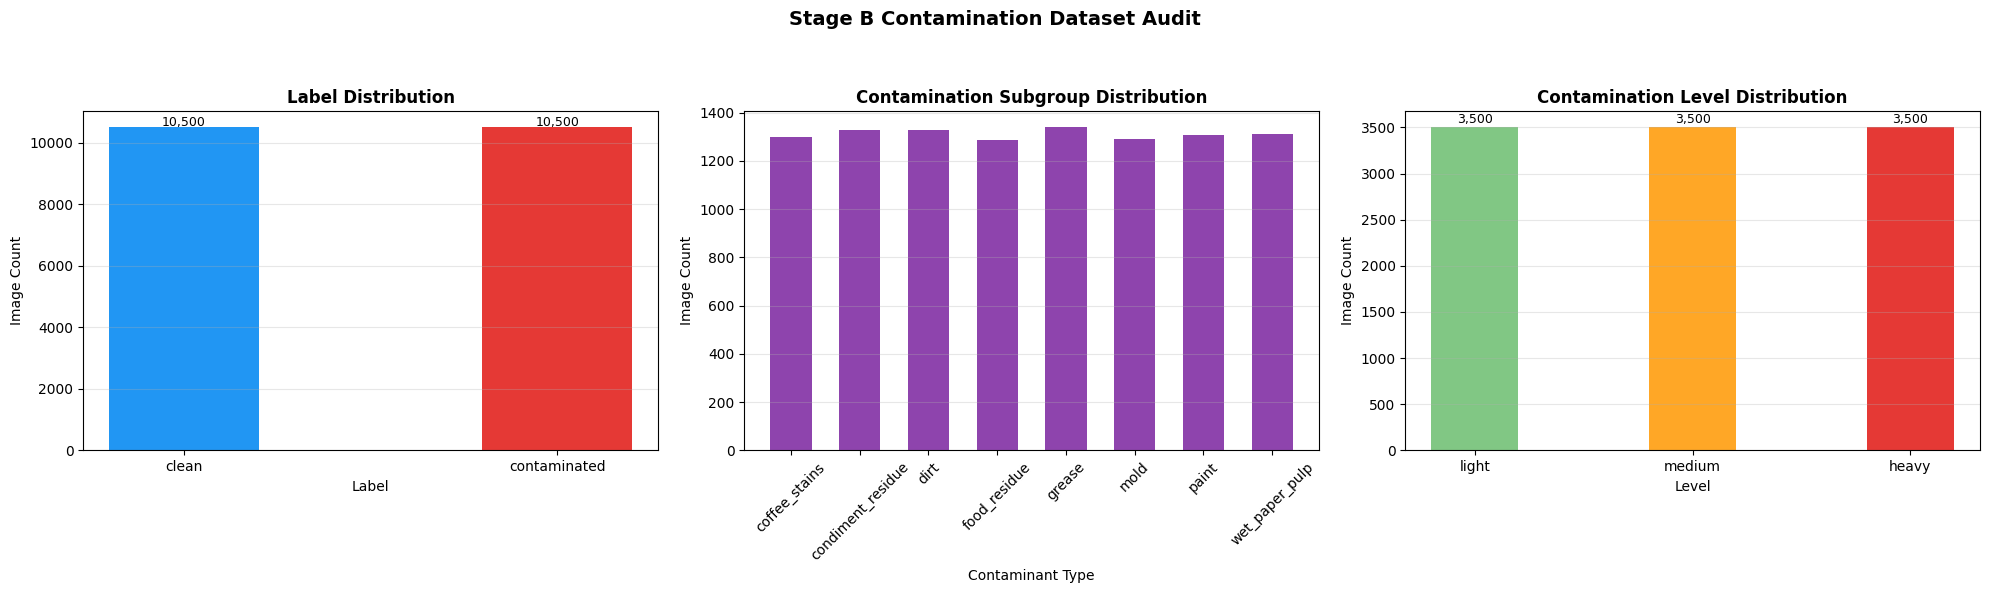

Saved to /kaggle/working/Synthetic Recyclable Contamination Dataset/dataset_audit.png


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Label distribution
axes[0].bar(label_counts.index, label_counts.values, color=['#2196F3', '#E53935'], width=0.4)
axes[0].set_title('Label Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Label', fontsize=10)
axes[0].set_ylabel('Image Count', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 50, f"{count:,}", ha='center', fontsize=9)

# Subgroup distribution
axes[1].bar(subgroup_counts.index, subgroup_counts.values, color='#8E44AD', width=0.6)
axes[1].set_title('Contamination Subgroup Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Contaminant Type', fontsize=10)
axes[1].set_ylabel('Image Count', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Level distribution
level_vals   = [level_counts.get(l, 0) for l in level_order]
level_colors = ['#81C784', '#FFA726', '#E53935']
axes[2].bar(level_order, level_vals, color=level_colors, width=0.4)
axes[2].set_title('Contamination Level Distribution', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Level', fontsize=10)
axes[2].set_ylabel('Image Count', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)
for i, count in enumerate(level_vals):
    axes[2].text(i, count + 50, f"{count:,}", ha='center', fontsize=9)

plt.suptitle('Stage B Contamination Dataset Audit', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])

# Save audit chart into the Synthetic dataset folder so it ships with the dataset
DATASET_ROOT.mkdir(parents=True, exist_ok=True)
audit_chart_path = DATASET_ROOT / 'dataset_audit.png'
plt.savefig(audit_chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {audit_chart_path}")

#### 3.10.5 Visual Sample Audit

Five random source images shown twice: clean on top, contaminated on bottom. A quick eyeball check that the texture patches landed on the object and look plausible.

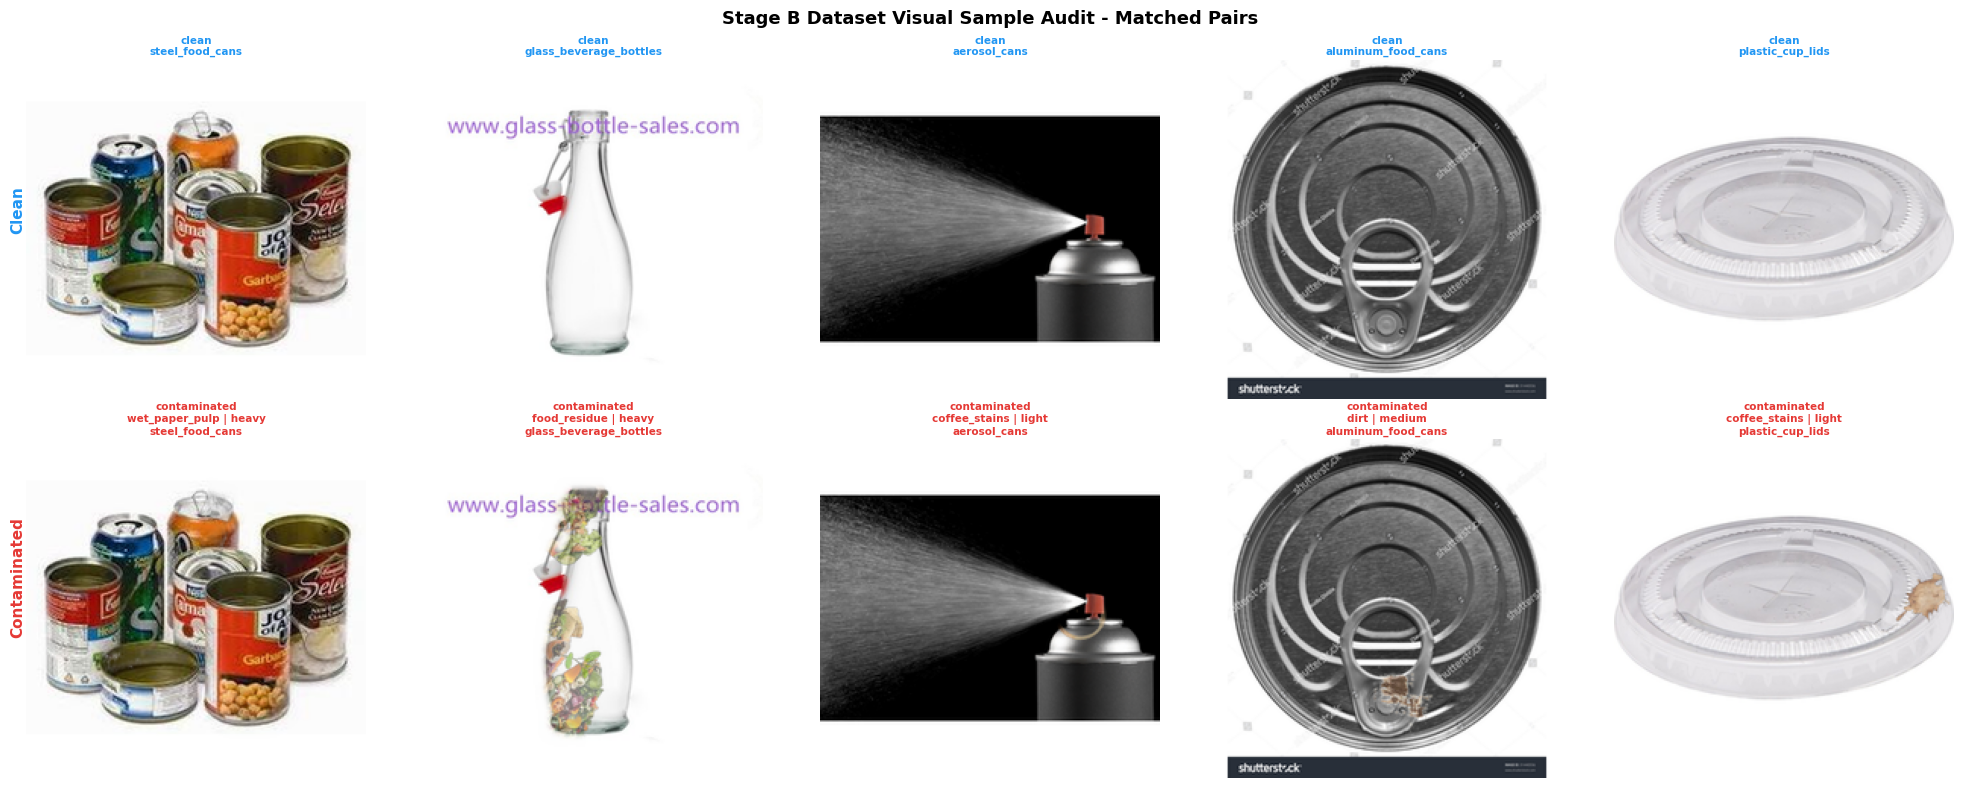

Saved to /kaggle/working/Synthetic Recyclable Contamination Dataset/visual_sample_audit.png


In [39]:
clean_rows = df_stage_b[df_stage_b['label'] == 'clean'].reset_index(drop=True)
cont_rows  = df_stage_b[df_stage_b['label'] == 'contaminated'].reset_index(drop=True)

sample_idx = random.sample(range(len(cont_rows)), min(5, len(cont_rows)))
pairs = [(clean_rows.iloc[i], cont_rows.iloc[i]) for i in sample_idx]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for col, (clean_row, cont_row) in enumerate(pairs):
    axes[0, col].imshow(Image.open(clean_row['image_path']).convert('RGB'))
    axes[0, col].axis('off')
    axes[0, col].set_title(f"clean\n{clean_row['source_class']}", fontsize=7.5,
                            color='#2196F3', fontweight='bold', pad=4)

    axes[1, col].imshow(Image.open(cont_row['image_path']).convert('RGB'))
    axes[1, col].axis('off')
    axes[1, col].set_title(
        f"contaminated\n{cont_row['subgroup']} | {cont_row['level']}\n{cont_row['source_class']}",
        fontsize=7.5, color='#E53935', fontweight='bold', pad=4
    )

fig.text(0.01, 0.73, 'Clean',        va='center', rotation='vertical', fontsize=11, fontweight='bold', color='#2196F3')
fig.text(0.01, 0.27, 'Contaminated', va='center', rotation='vertical', fontsize=11, fontweight='bold', color='#E53935')

plt.suptitle('Stage B Dataset Visual Sample Audit - Matched Pairs', fontsize=13, fontweight='bold')
plt.tight_layout()

# Save visual audit into the Synthetic dataset folder so it ships with the dataset
visual_audit_path = DATASET_ROOT / 'visual_sample_audit.png'
plt.savefig(visual_audit_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {visual_audit_path}")

### 3.11 Save Synthetic Recyclable Contamination Dataset

Copy every generated image into a single tree under `Synthetic Recyclable Contamination Dataset/images/` (split into `clean_recyclables/` and `contaminated_recyclables/` subfolders) and rewrite the manifest with paths relative to that root. This is the directory layout Step 4 reads from.

In [40]:
IMAGES_ROOT = DATASET_ROOT / 'images'
CLEAN_DIR   = IMAGES_ROOT / 'clean_recyclables'
CONTAM_DIR  = IMAGES_ROOT / 'contaminated_recyclables'

# Reset the final dataset directory so we start from a clean state
if IMAGES_ROOT.exists():
    shutil.rmtree(IMAGES_ROOT)
IMAGES_ROOT.mkdir(parents=True)

# ==- Clean images ==-
# Flatten {class}/default/Image_N.png to {class}/default_Image_N.png so both
# sides sit at the same directory depth
print("Copying clean images...")
total_clean = 0
for cls in tqdm(RECYCLABLE_CLASSES):
    src_cls = DATASET_PATH / cls
    dst_cls = CLEAN_DIR / cls
    if not src_cls.exists():
        print(f"  WARNING: {cls} not found - skipping")
        continue
    for f in src_cls.rglob('*'):
        if not f.is_file():
            continue
        flat_name = f"{f.parent.name}_{f.name}"
        dst_file  = dst_cls / flat_name
        dst_file.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(f, dst_file)
        total_clean += 1

# ==- Contaminated images ==-
print("\nCopying contaminated images...")
total_contam = 0
for img_file in tqdm(list((STAGE_B_PATH / 'contaminated').rglob('*.png'))):
    cls      = img_file.parent.name
    dst_file = CONTAM_DIR / cls / img_file.name
    dst_file.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(img_file, dst_file)
    total_contam += 1

# ==- Manifest ==-
# Rewrite image_path to paths relative to the dataset root so the CSV works
# outside the original Kaggle session
df_manifest = pd.read_csv(STAGE_B_PATH / 'stage_b_manifest.csv')

def to_relative_path(row):
    p = Path(row['image_path'])
    if row['label'] == 'clean':
        # Mirror the flattening applied above: {subfolder}_{filename}
        flat = f"{p.parent.name}_{p.name}"
        return f"images/clean_recyclables/{row['source_class']}/{flat}"
    return f"images/contaminated_recyclables/{row['source_class']}/{p.name}"

df_manifest['image_path'] = df_manifest.apply(to_relative_path, axis=1)
df_manifest.to_csv(DATASET_ROOT / 'stage_b_manifest.csv', index=False)

# ==- Clean up the intermediate Stage B Dataset directory ==-
# We no longer need it once the final dataset and manifest are assembled
if STAGE_B_PATH.exists():
    shutil.rmtree(STAGE_B_PATH)
    print(f"\nRemoved intermediate directory: {STAGE_B_PATH}")

# ==- Zip the final dataset for easy download ==-
zip_base = WORKING_PATH / 'Synthetic Recyclable Contamination Dataset'
zip_path = Path(shutil.make_archive(str(zip_base), 'zip', root_dir=str(DATASET_ROOT)))
print(f"Zipped dataset to {zip_path}")

# ==- Summary ==-
print(f"\nFinal directory structure:")
print(f"Synthetic Recyclable Contamination Dataset/")
print(f"|- stage_b_manifest.csv")
print(f"|- dataset_audit.png")
print(f"|- visual_sample_audit.png")
print(f"\\- images/")
print(f"    |- clean_recyclables/        {total_clean:>6,} images across {len(list(CLEAN_DIR.iterdir()))} classes")
print(f"    \\- contaminated_recyclables/ {total_contam:>6,} images across {len(list(CONTAM_DIR.iterdir()))} classes")

Copying clean images...


100%|██████████| 21/21 [00:16<00:00,  1.27it/s]



Copying contaminated images...


100%|██████████| 10500/10500 [00:02<00:00, 5026.36it/s]



Removed intermediate directory: /kaggle/working/Stage B Dataset
Zipped dataset to /kaggle/working/Synthetic Recyclable Contamination Dataset.zip

Final directory structure:
Synthetic Recyclable Contamination Dataset/
|-- stage_b_manifest.csv
|-- dataset_audit.png
|-- visual_sample_audit.png
\-- images/
    |-- clean_recyclables/        10,500 images across 21 classes
    \-- contaminated_recyclables/ 10,500 images across 21 classes


## Step 4: Train Stage B, the Contamination Classifier

### 4.1 Load and Split the Stage B Dataset

Free the Stage A artifacts from memory first so Stage B has room to load. Then build a source-aware 70/15/15 split: the split happens on unique source stems (not on individual files), so every clean copy and its 8 contaminated siblings always stay in the same split. Without this, the model could see a clean copy in training and the contaminated copy of the same object in validation, inflating the validation score.

Labels are encoded for a 9-class softmax: class 0 is clean and classes 1 through 8 are the 8 contaminant types in alphabetical order.

In [ ]:
# Free Stage A artifacts so Stage B has room to load
for _ds in ["train_ds", "val_ds", "test_ds", "test_default_ds", "test_real_world_ds"]:
    if _ds in globals():
        del globals()[_ds]
if "REMBG_SESSION" in globals():
    del REMBG_SESSION
for _name in ["model_a", "base_model", "best_model_a"]:
    if _name in globals():
        del globals()[_name]
gc.collect()
tf.keras.backend.clear_session()
print("Released Stage A artifacts from memory")

# Source-aware 70/15/15 split on unique source stems, stratified by recyclable class
manifest_b = df_stage_b.copy()
unique_sources = manifest_b[["source_stem", "source_class"]].drop_duplicates()

train_sources, temp_sources = train_test_split(
    unique_sources, test_size=0.30,
    stratify=unique_sources["source_class"], random_state=SEED,
)
val_sources, test_sources = train_test_split(
    temp_sources, test_size=0.50,
    stratify=temp_sources["source_class"], random_state=SEED,
)

train_stems = set(train_sources["source_stem"])
val_stems   = set(val_sources["source_stem"])
test_stems  = set(test_sources["source_stem"])

train_df_b = manifest_b[manifest_b["source_stem"].isin(train_stems)].reset_index(drop=True)
val_df_b   = manifest_b[manifest_b["source_stem"].isin(val_stems)  ].reset_index(drop=True)
test_df_b  = manifest_b[manifest_b["source_stem"].isin(test_stems) ].reset_index(drop=True)

# 9-class label encoding: clean is class 0, each contaminant type gets 1..8
contam_types        = sorted(manifest_b[manifest_b["label"] == "contaminated"]["subgroup"].unique())
class_names_b       = ["clean"] + contam_types
CLEAN_CLASS_IDX     = 0
NUM_STAGE_B_CLASSES = len(class_names_b)
subgroup_to_idx     = {name: i for i, name in enumerate(class_names_b)}


def _encode(row):
    if row["label"] == "clean":
        return CLEAN_CLASS_IDX
    return subgroup_to_idx[row["subgroup"]]


for df in (train_df_b, val_df_b, test_df_b):
    df["label_idx"] = df.apply(_encode, axis=1).astype(np.int32)

print(f"Stage B classes ({NUM_STAGE_B_CLASSES}): {class_names_b}")
print(f"Unique sources : train={len(train_stems):,}  val={len(val_stems):,}  test={len(test_stems):,}")
print(f"Total images   : train={len(train_df_b):,}  val={len(val_df_b):,}  test={len(test_df_b):,}")


# Build tf.data datasets from (file_path, label_idx) tensor slices
AUTOTUNE = tf.data.AUTOTUNE


def _load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.int32)


def _build_ds(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df["image_path"].values, df["label_idx"].values))
    if shuffle:
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.map(_load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)


train_b_ds = _build_ds(train_df_b, shuffle=True)
val_b_ds   = _build_ds(val_df_b).cache()
test_b_ds  = _build_ds(test_df_b).cache()


### 4.2 Data Augmentation

Stage B reuses the same augmentation pipeline defined in section 2.2. Augmentation lives inside the model graph and is automatically disabled during evaluation, so no separate code cell is needed here.

### 4.3 Build the Stage B Contamination Classifier

Stage B reuses the trained Stage A backbone (the part of the model that already understands what waste items look like) and replaces only the classification head. The new head outputs 9 probabilities: one for clean and one for each contaminant type. The backbone stays frozen so Stage B can converge quickly without disturbing Stage A\'s features.

| Layer | Output Shape | Trainable Params |
|-|-|-|
| Input | (None, 224, 224, 3) | 0 |
| Augmentation | (None, 224, 224, 3) | 0 |
| EfficientNetB0 backbone (frozen) | (None, 7, 7, 1280) | 0 |
| GlobalAveragePooling2D | (None, 1280) | 0 |
| BatchNormalization | (None, 1280) | 5,120 |
| Dropout(0.5) | (None, 1280) | 0 |
| Dense(256, ReLU + L2) | (None, 256) | 327,936 |
| Dropout(0.3) | (None, 256) | 0 |
| Dense(9, softmax) | (None, 9) | 2,313 |

In [ ]:
def build_stage_b(stage_a_weights_path):
    stage_a  = tf.keras.models.load_model(stage_a_weights_path)
    # Find the EfficientNet backbone inside the Stage A model regardless of
    # what Keras serialised its name as
    backbone = next(
        l for l in stage_a.layers
        if isinstance(l, tf.keras.Model) and "efficientnet" in l.name.lower()
    )
    backbone.trainable = False

    inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = data_augmentation(inputs)
    x       = backbone(x, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.5)(x)
    x       = layers.Dense(256, activation="relu",
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_STAGE_B_CLASSES, activation="softmax",
                           name="contamination")(x)
    model   = Model(inputs, outputs, name="stage_b")

    del stage_a
    gc.collect()
    return model, backbone


model_b, backbone_b = build_stage_b(MODELS_PATH / "stage_a_best.keras")
model_b.summary()


### 4.4 Define Callbacks

Same three callbacks as Stage A. All three monitor `val_accuracy` instead of `val_auc` because the 9-class softmax does not have a single ROC-AUC.

In [ ]:
checkpoint_b_cb = ModelCheckpoint(
    str(MODELS_PATH / "stage_b_best.keras"),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

early_stop_b_cb = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
)

reduce_lr_b_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1,
)


### 4.5 Stage B Model Training

Train Stage B for up to 18 epochs with Adam (lr=1e-3, clipnorm=1.0) and sparse categorical cross-entropy. Class weights are computed with scikit-learn\'s `balanced` strategy so the over-represented clean class does not dominate the gradient. Wall-clock on Kaggle T4 is roughly **XX minutes**.

In [ ]:
print("Training Stage B")
backbone_b.trainable = False

# Clean appears in every source while each contaminant appears only 1/8 of the
# time. Balanced class weights restore equal influence per class.
cw_values = compute_class_weight(
    "balanced",
    classes=np.arange(NUM_STAGE_B_CLASSES),
    y=train_df_b["label_idx"].values,
)
class_weights_b = dict(enumerate(cw_values))
print("Class weights:", {class_names_b[k]: round(v, 2) for k, v in class_weights_b.items()})

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_b = model_b.fit(
    train_b_ds,
    epochs=18,
    validation_data=val_b_ds,
    callbacks=[checkpoint_b_cb, early_stop_b_cb, reduce_lr_b_cb],
    class_weight=class_weights_b,
    verbose=1,
)
print(f"\nBest Stage B checkpoint saved to: {MODELS_PATH / 'stage_b_best.keras'}")


### 4.6 Plot Training vs Validation Error Metrics

Accuracy and loss curves for the 9-class head, side by side. A widening train/val gap means the model is starting to memorise the synthetic textures, which is the failure mode most likely to hurt real-world contamination detection.

In [ ]:
epochs_b = range(1, len(history_b.history["accuracy"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_b, history_b.history["accuracy"],     label="Train", color="steelblue")
ax1.plot(epochs_b, history_b.history["val_accuracy"], label="Val",   color="tomato")
ax1.set_title("Stage B Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_b, history_b.history["loss"],     label="Train", color="steelblue")
ax2.plot(epochs_b, history_b.history["val_loss"], label="Val",   color="tomato")
ax2.set_title("Stage B Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Stage B Contamination Classifier Error Metrics",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(STAGE_B_RESULTS_PATH / "stage_b_error_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.7 Evaluate Stage B on the Test Set

Load the best checkpoint and report per-class accuracy, precision, recall, and F1 for all 9 classes. A binary collapse (`P(contaminated) = 1 - P(clean)`) is also computed for ROC-AUC and for any downstream threshold tuning the dashboard might do.

In [ ]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)

best_model_b = tf.keras.models.load_model(MODELS_PATH / "stage_b_best.keras")

# Build aligned probability matrix and labels
all_b_probs_mat, all_b_labels = [], []
for images, labels in test_b_ds:
    probs = best_model_b.predict(images, verbose=0)
    all_b_probs_mat.extend(probs.tolist())
    all_b_labels.extend(labels.numpy().astype(int).flatten().tolist())

all_b_probs_mat = np.array(all_b_probs_mat)
all_b_labels    = np.array(all_b_labels)
all_b_preds     = np.argmax(all_b_probs_mat, axis=1)

# Binary collapse for the downstream "is it contaminated" decision
all_b_contam_probs  = 1.0 - all_b_probs_mat[:, CLEAN_CLASS_IDX]
all_b_binary_labels = (all_b_labels != CLEAN_CLASS_IDX).astype(int)

# Per-class metrics
cm_b            = confusion_matrix(all_b_labels, all_b_preds,
                                   labels=list(range(NUM_STAGE_B_CLASSES)))
per_class_acc_b = cm_b.diagonal() / cm_b.sum(axis=1).clip(min=1)

rows = []
for i, name in enumerate(class_names_b):
    rows.append({
        "Class":     name,
        "Accuracy":  per_class_acc_b[i],
        "Precision": precision_score(all_b_labels == i, all_b_preds == i, zero_division=0),
        "Recall":    recall_score(all_b_labels == i,    all_b_preds == i, zero_division=0),
        "F1":        f1_score(all_b_labels == i,        all_b_preds == i, zero_division=0),
    })

df_b_metrics = pd.DataFrame(rows)
overall_acc  = (all_b_preds == all_b_labels).mean()
auc_b        = roc_auc_score(all_b_binary_labels, all_b_contam_probs)

print(df_b_metrics.to_string(index=False))
print(f"\nOverall Accuracy : {overall_acc:.4f}")
print(f"Binary ROC-AUC   : {auc_b:.4f}  (clean vs contaminated collapse)")

# Results DataFrame for sections 4.8 and 4.9
results_b               = test_df_b.copy().reset_index(drop=True)
results_b["true_label"] = all_b_labels
results_b["pred_label"] = all_b_preds
results_b["prob"]       = all_b_contam_probs


In [ ]:
display_names = class_names_b
metric_labels = ["Accuracy", "Precision", "Recall", "F1"]
bar_colors    = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
x             = np.arange(len(display_names))
width         = 0.18

fig, ax = plt.subplots(figsize=(14, 5))
for i, (metric, color) in enumerate(zip(metric_labels, bar_colors)):
    ax.bar(x + i * width, df_b_metrics[metric].values, width,
           label=metric, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(display_names, fontsize=10, rotation=30, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Stage B: Per-Class Evaluation Metrics", fontweight="bold")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(STAGE_B_RESULTS_PATH / "stage_b_per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.8 Per-Contamination-Level Breakdown

A secondary view that asks how Stage B does on light, medium, and heavy contamination separately. **Flag Rate** is the binary metric (did the model predict any non-clean class for this image?) and **Type Accuracy** is the exact-match metric (did the model also pick the correct contaminant type?). Heavier contamination should be easier to flag.

In [ ]:
cont_results = results_b[results_b["label"] == "contaminated"].copy()
cont_results["correctly_flagged"] = cont_results["pred_label"] != CLEAN_CLASS_IDX
cont_results["exact_class_match"] = cont_results["pred_label"] == cont_results["true_label"]

level_order = ["light", "medium", "heavy"]
level_rows  = []
for level in level_order:
    lvl_df = cont_results[cont_results["level"] == level]
    if len(lvl_df) == 0:
        continue
    level_rows.append({
        "Level":             level,
        "n":                 len(lvl_df),
        "Flag Rate":         lvl_df["correctly_flagged"].mean(),
        "Type Accuracy":     lvl_df["exact_class_match"].mean(),
    })

df_level = pd.DataFrame(level_rows)
print(df_level.to_string(index=False))

x      = np.arange(len(df_level))
width  = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, df_level["Flag Rate"].values,     width,
       label="Flag Rate (any contamination)", color="#2196F3")
ax.bar(x + width / 2, df_level["Type Accuracy"].values, width,
       label="Exact Type Accuracy",           color="#FF9800")
ax.set_xticks(x)
ax.set_xticklabels(df_level["Level"].values)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Stage B: Performance by Contamination Severity", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(STAGE_B_RESULTS_PATH / "stage_b_by_level.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.9 Per-Recyclable-Class Breakdown

Break down Stage B by the underlying recyclable class. Some classes (cardboard, paper) take texture more visibly than others (smooth plastic), so Stage B may flag contamination on some surfaces more reliably than on others.

In [ ]:
class_rows = []
for cls in sorted(results_b["source_class"].dropna().unique()):
    cls_df   = results_b[results_b["source_class"] == cls]
    clean_df = cls_df[cls_df["label"] == "clean"]
    cont_df  = cls_df[cls_df["label"] == "contaminated"]

    overall_acc = (cls_df["pred_label"] == cls_df["true_label"]).mean()
    clean_acc   = (clean_df["pred_label"] == CLEAN_CLASS_IDX).mean() if len(clean_df) > 0 else float("nan")
    cont_flag   = (cont_df["pred_label"] != CLEAN_CLASS_IDX).mean() if len(cont_df) > 0 else float("nan")

    class_rows.append({
        "Class":          cls,
        "n":              len(cls_df),
        "Exact 9-class":  overall_acc,
        "Clean Recall":   clean_acc,
        "Contam. Flag":   cont_flag,
    })

df_class = (
    pd.DataFrame(class_rows)
    .sort_values("Exact 9-class", ascending=False)
    .reset_index(drop=True)
)
print(df_class.to_string(index=False))

x     = np.arange(len(df_class))
width = 0.28

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, df_class["Exact 9-class"], width, label="Exact 9-class",  color="#2196F3")
ax.bar(x,         df_class["Clean Recall"],  width, label="Clean Recall",   color="#4CAF50")
ax.bar(x + width, df_class["Contam. Flag"],  width, label="Contam. Flag",   color="#E53935")

ax.set_xticks(x)
ax.set_xticklabels(df_class["Class"].values, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Stage B: Performance by Recyclable Class", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(STAGE_B_RESULTS_PATH / "stage_b_by_class.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 5: Package Outputs for Download

Bundles the trained Stage A and Stage B checkpoints, the dataset manifest, and every figure produced during evaluation into a single zip file. When Run All finishes, this archive appears in the Kaggle session\'s output panel for one-click download.

In [ ]:
import zipfile

OUTPUT_ZIP = WORKING_PATH / "ecobin_outputs.zip"
if OUTPUT_ZIP.exists():
    OUTPUT_ZIP.unlink()

# Directories that get walked into the zip
roots = [
    (MODELS_PATH,          "Models"),
    (STAGE_A_RESULTS_PATH, "Stage A Results"),
    (STAGE_B_RESULTS_PATH, "Stage B Results"),
    (DATASET_AUDIT_PATH,   "Waste Classification Dataset Audit"),
]

# Individual files we also want included
extras = [
    DATASET_ROOT / "stage_b_manifest.csv",
]

with zipfile.ZipFile(OUTPUT_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, label in roots:
        if not root.exists():
            continue
        for f in root.rglob("*"):
            if f.is_file():
                zf.write(f, arcname=f"{label}/{f.relative_to(root)}")
    for f in extras:
        if f.exists():
            zf.write(f, arcname=f"Synthetic Recyclable Contamination Dataset/{f.name}")

size_mb = OUTPUT_ZIP.stat().st_size / (1024 * 1024)
print(f"Wrote {OUTPUT_ZIP} ({size_mb:.1f} MB)")
